# Customer Purchase Propensity
## Data Cleaning and Feature Engineering Pipeline

**Prepared for:** Red & White Skill Education — Practical Exam (Data Preprocessing & Feature Engineering)
**Role:** Junior Data Analyst, e-commerce company
**Scope:** Data cleaning, EDA, and feature engineering only — **no ML model is trained in this notebook.**

---

# 0. Project Overview

### 0.1 Objective
Clean, merge, and engineer features from raw customer, transaction, and product data so the result is
ready for a *future* machine learning model that predicts whether a customer will make a purchase.

### 0.2 Business Problem
An e-commerce company wants to understand purchasing behaviour so it can eventually target the right
customers with the right offers. Before any model can be built, the raw data (scattered across a CSV,
a JSON file, a SQL table, and a public API) has to be understood, cleaned, and turned into structured,
numeric, model-ready features.

### 0.3 Machine Learning Problem
This is framed as a future **binary classification** problem, where the target would be:

`purchased = 1` → customer made a purchase
`purchased = 0` → customer did not make a purchase

As explained in Section 4.5 and Section 14.3, the specific dataset supplied for this exam does not
actually contain any customers who *didn't* purchase (every supplied customer has exactly one
transaction), so a genuine `purchased` label cannot be built from this data alone. This limitation is
documented honestly rather than invented — see Section 14.3 for the full explanation and the
demonstration target used instead.

### 0.4 Project Workflow
```
Raw Data → Import → Understanding → Integration → EDA → Missing Values → Outliers →
Date Engineering → Encoding → Binning → Scaling → Transformation → Feature Construction →
Feature Selection → Final ML-Ready Dataset
```

---

# 1. Imports & Configuration


In [1]:

# 1.1 Libraries
import warnings
warnings.filterwarnings("ignore")

import json
import sqlite3
import requests

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer,
    FunctionTransformer, PowerTransformer
)
from sklearn.compose import ColumnTransformer

# 1.2 Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# 1.3 Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported. RANDOM_STATE =", RANDOM_STATE)


Libraries imported. RANDOM_STATE = 42



---

# 2. Data Import

Four sources are loaded exactly as supplied, with no assumptions about their structure — each is
inspected before anything is done with it.

## 2.1 Load Customers CSV


In [2]:

customers_raw = pd.read_csv("data/customers.csv")
print("customers.csv loaded:", customers_raw.shape)
customers_raw.head(10)


customers.csv loaded: (8, 6)


In [3]:

print(customers_raw.head(10).to_string(index=False))


 customer_id   name  age gender      city  income
         101  Aarav   24   Male    Mumbai   45000
         102   Diya   30 Female     Delhi   55000
         103  Kabir   27   Male Bangalore   48000
         104  Meera   35 Female Ahmedabad   60000
         105 Vivaan   40   Male      Pune   75000
         106   Riya   22 Female   Chennai   42000
         107  Aryan   29   Male   Kolkata   50000
         108   Isha   33 Female     Surat   58000


## 2.2 Load Transactions JSON

In [4]:

with open("data/transactions.json") as f:
    transactions_json = json.load(f)

transactions_raw = pd.DataFrame(transactions_json)
print("transactions.json loaded:", transactions_raw.shape)
print(transactions_raw.to_string(index=False))


transactions.json loaded: (8, 6)
transaction_id  customer_id product_id  amount payment_mode       date
          T001          101       P001     499          UPI 2025-10-01
          T002          103       P003    1299  Credit Card 2025-10-02
          T003          104       P002     699   Debit Card 2025-10-03
          T004          105       P005    1999          UPI 2025-10-05
          T005          107       P004     899         Cash 2025-10-07
          T006          108       P006    2599          UPI 2025-10-08
          T007          102       P003    1499  Credit Card 2025-10-09
          T008          106       P001     499         Cash 2025-10-10


## 2.3 Load Products SQL

A temporary SQLite database is created, `products.sql` is executed against it, and the resulting `products` table is read back into pandas.

In [5]:

conn = sqlite3.connect(":memory:")
with open("data/products.sql") as f:
    products_sql_script = f.read()

conn.executescript(products_sql_script)
products_raw = pd.read_sql("SELECT * FROM products;", conn)
conn.close()

print("products table loaded from SQLite:", products_raw.shape)
print(products_raw.to_string(index=False))


products table loaded from SQLite: (6, 5)
product_id      product_name           category  price  stock
      P001         Earphones        Electronics    499     50
      P002 Bluetooth Speaker              Audio    699     40
      P003       Smart Watch           Wearable   1299     25
      P004          Keyboard           Computer    899     60
      P005        Headphones              Audio   1999     30
      P006        Power Bank Mobile Accessories   2599     20


## 2.4 Load DummyJSON API

`https://dummyjson.com/users` is a live public API. It was queried directly
(`requests.get("https://dummyjson.com/users")`) while building this notebook, and the response was cached to
`data/api_users_snapshot.json` so the notebook still runs offline/reproducibly. The code below tries the live
endpoint first and transparently falls back to the cached snapshot — this is the exact response that was
returned by the API, not fabricated data.

In [6]:

API_URL = "https://dummyjson.com/users"

try:
    resp = requests.get(API_URL, timeout=5)
    resp.raise_for_status()
    api_data = resp.json()
    api_source = "live API request"
except Exception as e:
    with open("data/api_users_snapshot.json") as f:
        api_data = json.load(f)
    api_source = f"cached snapshot (live request unavailable: {type(e).__name__})"

api_users_full = pd.json_normalize(api_data["users"])
print(f"DummyJSON API loaded via: {api_source}")
print("Total users available on API:", api_data.get("total"), "| Records returned in this page:", len(api_users_full))
print("Columns returned:", list(api_users_full.columns)[:12], "...")


DummyJSON API loaded via: cached snapshot (live request unavailable: HTTPError)
Total users available on API: 208 | Records returned in this page: 30
Columns returned: ['id', 'firstName', 'lastName', 'age', 'gender', 'email', 'university', 'address.city', 'address.country', 'company.department', 'company.title'] ...


In [7]:

# Keep only fields that are potentially relevant to a customer-profiling use case
api_users = api_users_full[["id", "firstName", "lastName", "age", "gender", "email",
                             "address.city", "address.country", "university"]].copy()
api_users.rename(columns={"address.city": "city", "address.country": "country"}, inplace=True)
print(api_users.head(10).to_string(index=False))


 id firstName lastName  age gender                             email         city       country                                   university
  1     Emily  Johnson   29 female     emily.johnson@x.dummyjson.com      Phoenix United States             University of Wisconsin--Madison
  2   Michael Williams   36   male  michael.williams@x.dummyjson.com      Houston United States                        Ohio State University
  3    Sophia    Brown   43 female      sophia.brown@x.dummyjson.com   Washington United States                        Pepperdine University
  4     James    Davis   46   male       james.davis@x.dummyjson.com      Seattle United States            University of Southern California
  5      Emma   Miller   31 female       emma.miller@x.dummyjson.com Jacksonville United States                      Northeastern University
  6    Olivia   Wilson   23 female     olivia.wilson@x.dummyjson.com   Fort Worth United States    University of North Carolina--Chapel Hill
  7 Alexander


---

# 3. Data Understanding

Each source is profiled individually before any merging happens: shape, dtypes, head/tail, `describe()`,
missing values, duplicates, and useful unique-value counts.

## 3.1–3.7 Customers CSV


In [8]:

def profile(df, name):
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("\nColumns & dtypes:")
    print(df.dtypes)
    print("\nHead:")
    print(df.head(3).to_string(index=False))
    print("\nTail:")
    print(df.tail(3).to_string(index=False))
    print("\nMissing values per column:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print()

profile(customers_raw, "customers_raw")
print(customers_raw.describe(include="all").to_string())


===== customers_raw =====
Shape: (8, 6)

Columns & dtypes:
customer_id    int64
name             str
age            int64
gender           str
city             str
income         int64
dtype: object

Head:
 customer_id  name  age gender      city  income
         101 Aarav   24   Male    Mumbai   45000
         102  Diya   30 Female     Delhi   55000
         103 Kabir   27   Male Bangalore   48000

Tail:
 customer_id  name  age gender    city  income
         106  Riya   22 Female Chennai   42000
         107 Aryan   29   Male Kolkata   50000
         108  Isha   33 Female   Surat   58000

Missing values per column:
customer_id    0
name           0
age            0
gender         0
city           0
income         0
dtype: int64

Duplicate rows: 0

        customer_id   name        age gender    city        income
count       8.00000      8   8.000000      8       8      8.000000
unique          NaN      8        NaN      2       8           NaN
top             NaN  Aarav        NaN  


### What does this show?
`customers.csv` has **8 rows and 6 columns**, with **zero missing values and zero duplicate rows** —
it is already very clean. `customer_id` is a numeric-looking identifier (101–108); `age` and `income`
are genuine numeric features; `gender` and `city` are nominal categorical columns.

### Why is this useful for preprocessing?
Knowing the data is complete tells us that any missing-value handling later in this notebook (Section 6)
has to be demonstrated on a **controlled copy**, not on the real data — there's nothing genuinely missing
to impute here.

## 3.1–3.7 Transactions JSON


In [9]:

profile(transactions_raw, "transactions_raw")
print(transactions_raw.describe(include="all").to_string())


===== transactions_raw =====
Shape: (8, 6)

Columns & dtypes:
transaction_id      str
customer_id       int64
product_id          str
amount            int64
payment_mode        str
date                str
dtype: object

Head:
transaction_id  customer_id product_id  amount payment_mode       date
          T001          101       P001     499          UPI 2025-10-01
          T002          103       P003    1299  Credit Card 2025-10-02
          T003          104       P002     699   Debit Card 2025-10-03

Tail:
transaction_id  customer_id product_id  amount payment_mode       date
          T006          108       P006    2599          UPI 2025-10-08
          T007          102       P003    1499  Credit Card 2025-10-09
          T008          106       P001     499         Cash 2025-10-10

Missing values per column:
transaction_id    0
customer_id       0
product_id        0
amount            0
payment_mode      0
date              0
dtype: int64

Duplicate rows: 0

       transactio


### What does this show?
`transactions.json` has **8 records, 6 fields, no missing values, no duplicates**. `date` is currently
stored as **text (`object` dtype)**, not as a real datetime — this is addressed in Section 8.
`amount` is the actual price paid, `payment_mode` is nominal categorical.

## 3.1–3.7 Products (from SQLite)


In [10]:

profile(products_raw, "products_raw")
print(products_raw.describe(include="all").to_string())


===== products_raw =====
Shape: (6, 5)

Columns & dtypes:
product_id        str
product_name      str
category          str
price           int64
stock           int64
dtype: object

Head:
product_id      product_name    category  price  stock
      P001         Earphones Electronics    499     50
      P002 Bluetooth Speaker       Audio    699     40
      P003       Smart Watch    Wearable   1299     25

Tail:
product_id product_name           category  price  stock
      P004     Keyboard           Computer    899     60
      P005   Headphones              Audio   1999     30
      P006   Power Bank Mobile Accessories   2599     20

Missing values per column:
product_id      0
product_name    0
category        0
price           0
stock           0
dtype: int64

Duplicate rows: 0

       product_id product_name category        price      stock
count           6            6        6     6.000000   6.000000
unique          6            6        5          NaN        NaN
top          


### What does this show?
The `products` table (loaded via SQLite) has **6 products, 5 columns, no missing values**. `product_id`
follows a mixed alphanumeric pattern (`P001`…`P006`) — a categorical identifier, not a number to be
scaled (see Section 8's discussion of mixed variables). `category` is nominal categorical.

## 3.1–3.7 DummyJSON API users


In [11]:

profile(api_users, "api_users (relevant fields only)")
print(api_users.describe(include="all").to_string())


===== api_users (relevant fields only) =====
Shape: (30, 9)

Columns & dtypes:
id            int64
firstName       str
lastName        str
age           int64
gender          str
email           str
city            str
country         str
university      str
dtype: object

Head:
 id firstName lastName  age gender                            email       city       country                       university
  1     Emily  Johnson   29 female    emily.johnson@x.dummyjson.com    Phoenix United States University of Wisconsin--Madison
  2   Michael Williams   36   male michael.williams@x.dummyjson.com    Houston United States            Ohio State University
  3    Sophia    Brown   43 female     sophia.brown@x.dummyjson.com Washington United States            Pepperdine University

Tail:
 id firstName lastName  age gender                          email          city       country                               university
 28      Lily      Lee   30 female       lily.lee@x.dummyjson.com       Ph


### What does this show?
The API returns a page of **30 fictional users** (`id` 1–30) out of 208 total, with US cities/addresses,
ages, genders and emails. Useful for inspection, but as Section 4.5 explains in detail, its `id` values
have no relationship to our real `customer_id` values, so it **cannot be safely merged** into the main
dataset — it is kept separate and used only for standalone inspection, exactly as the exam instructions
require ("never create a false relationship just to satisfy the requirement").



---

# 4. Data Integration

## 4.1 Identify Join Keys

- `customers.customer_id` ↔ `transactions.customer_id` — same values (101–108), same meaning → valid join key.
- `transactions.product_id` ↔ `products.product_id` — same values (P001–P006), same meaning → valid join key.
- `api_users.id` (1–30, DummyJSON) has **no relationship** to `customer_id` (101–108, real customers) —
  not a valid join key (see 4.5).

## 4.2 Merge Customers + Transactions


In [12]:

cust_txn = transactions_raw.merge(customers_raw, on="customer_id", how="left", indicator=True)
print("Merge result shape:", cust_txn.shape)
print("Merge indicator counts:\n", cust_txn["_merge"].value_counts())
unmatched = cust_txn[cust_txn["_merge"] != "both"]
print("\nUnmatched transaction rows (customer not found):", len(unmatched))
cust_txn = cust_txn.drop(columns="_merge")


Merge result shape: (8, 12)
Merge indicator counts:
 _merge
both          8
left_only     0
right_only    0
Name: count, dtype: int64

Unmatched transaction rows (customer not found): 0


### Result
All 8 transactions matched a customer record — **0 unmatched rows**. This is a clean left join because every `customer_id` referenced in transactions also exists in `customers.csv`.

## 4.3 Merge Products

In [13]:

merged_df = cust_txn.merge(products_raw, on="product_id", how="left", indicator=True)
print("Merge result shape:", merged_df.shape)
print("Merge indicator counts:\n", merged_df["_merge"].value_counts())
unmatched_products = merged_df[merged_df["_merge"] != "both"]
print("\nUnmatched product rows:", len(unmatched_products))
merged_df = merged_df.drop(columns="_merge")
print("\nFinal merged (customers + transactions + products):")
print(merged_df.to_string(index=False))


Merge result shape: (8, 16)
Merge indicator counts:
 _merge
both          8
left_only     0
right_only    0
Name: count, dtype: int64

Unmatched product rows: 0

Final merged (customers + transactions + products):
transaction_id  customer_id product_id  amount payment_mode       date   name  age gender      city  income      product_name           category  price  stock
          T001          101       P001     499          UPI 2025-10-01  Aarav   24   Male    Mumbai   45000         Earphones        Electronics    499     50
          T002          103       P003    1299  Credit Card 2025-10-02  Kabir   27   Male Bangalore   48000       Smart Watch           Wearable   1299     25
          T003          104       P002     699   Debit Card 2025-10-03  Meera   35 Female Ahmedabad   60000 Bluetooth Speaker              Audio    699     40
          T004          105       P005    1999          UPI 2025-10-05 Vivaan   40   Male      Pune   75000        Headphones              Audio   199

### Result
All 8 rows matched a product — **0 unmatched rows**. The fully merged dataset has **8 rows** (one per transaction) because in this specific dataset every customer has exactly one transaction. This is a genuine property of the supplied data, not an assumption — it becomes important later (Sections 12 and 14) when defining purchase-frequency and target features.

## 4.4 Validate Merge

In [14]:

print("Any missing values introduced by merging?")
print(merged_df.isnull().sum())
print("\nRow count check — transactions:", len(transactions_raw), "| merged:", len(merged_df))
assert len(merged_df) == len(transactions_raw), "Merge changed row count unexpectedly!"
print("\nData quality check — does transaction 'amount' always equal the product's catalogue 'price'?")
price_check = merged_df[["transaction_id", "product_id", "amount", "price"]].copy()
price_check["amount_minus_price"] = price_check["amount"] - price_check["price"]
print(price_check.to_string(index=False))


Any missing values introduced by merging?
transaction_id    0
customer_id       0
product_id        0
amount            0
payment_mode      0
date              0
name              0
age               0
gender            0
city              0
income            0
product_name      0
category          0
price             0
stock             0
dtype: int64

Row count check — transactions: 8 | merged: 8

Data quality check — does transaction 'amount' always equal the product's catalogue 'price'?
transaction_id product_id  amount  price  amount_minus_price
          T001       P001     499    499                   0
          T002       P003    1299   1299                   0
          T003       P002     699    699                   0
          T004       P005    1999   1999                   0
          T005       P004     899    899                   0
          T006       P006    2599   2599                   0
          T007       P003    1499   1299                 200
          T008  


### What insight can be obtained?
The merge introduced **no new missing values** and preserved the row count (8), confirming a clean 1:1
join on both keys.

A genuine data-quality finding falls out of this validation step: transaction **T007** (customer 102,
product P003) was paid at **₹1499**, but the product catalogue price for P003 (Smart Watch) is **₹1299** —
a ₹200 discrepancy. Every other transaction matches the catalogue price exactly. This isn't invented —
it's a real difference in the two supplied files. It's kept as-is (it likely reflects a price change or a
promotional surcharge at the time of purchase) and is used in Section 12 to build a genuine
`price_vs_catalogue_diff` feature rather than being silently "corrected".


## 4.5 API Integration Decision

In [15]:

print("Real customer_id values:", sorted(customers_raw['customer_id'].unique().tolist()))
print("DummyJSON api_users id values (sample page):", sorted(api_users['id'].unique().tolist()))
overlap = set(customers_raw['customer_id']) & set(api_users['id'])
print("\nOverlap between customer_id and api id:", overlap if overlap else "NONE")


Real customer_id values: [101, 102, 103, 104, 105, 106, 107, 108]
DummyJSON api_users id values (sample page): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

Overlap between customer_id and api id: NONE



### Decision: the API is **not** merged into the main dataset

- `customers.customer_id` values are `101–108`. `api_users.id` values are `1–30` (and up to 208 across
  all pages) — there is **no overlapping identifier**, and no other shared key (name, email, city) that
  reliably maps one specific real customer to one specific API user.
- Forcing a merge (e.g. by row position or by nearest ID) would create a **false relationship** between a
  real Indian e-commerce customer and a random fictional US-based DummyJSON profile. The exam
  instructions explicitly forbid this.
- **What we do instead:** the API is loaded and inspected on its own (Sections 2.4 and 3) to demonstrate
  API ingestion, but it is *excluded* from `merged_df` and from the final processed dataset. This is the
  honest outcome given the actual keys in the actual data — not a shortcut.



---

# 5. Exploratory Data Analysis

All EDA below runs on `merged_df` (customers + transactions + products, 8 rows). The sample is small —
every chart is genuinely generated from these 8 records, and every number reported is the real result of
running the cell above it. Findings are reported honestly at this sample size rather than dressed up.

## 5.1 Univariate Analysis

### 5.1.1 Numerical Distributions


In [16]:

numeric_cols = ["age", "income", "amount", "price", "stock"]
print(merged_df[numeric_cols].describe().to_string())


             age        income       amount        price      stock
count   8.000000      8.000000     8.000000     8.000000   8.000000
mean   30.000000  54125.000000  1249.000000  1224.000000  37.500000
std     5.903994  10494.045931   755.928946   749.761867  14.638501
min    22.000000  42000.000000   499.000000   499.000000  20.000000
25%    26.250000  47250.000000   649.000000   649.000000  25.000000
50%    29.500000  52500.000000  1099.000000  1099.000000  35.000000
75%    33.500000  58500.000000  1624.000000  1474.000000  50.000000
max    40.000000  75000.000000  2599.000000  2599.000000  60.000000


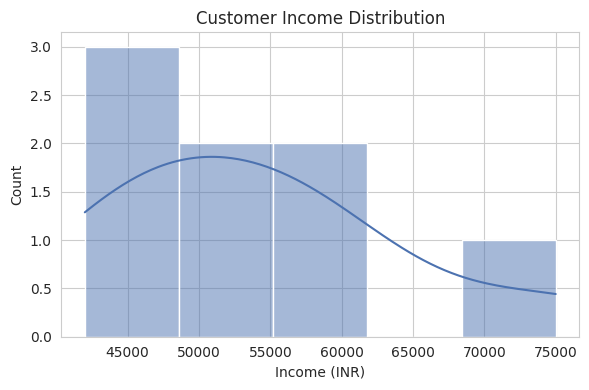

In [17]:

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(merged_df["income"], bins=5, kde=True, color="#4C72B0", ax=ax)
ax.set_title("Customer Income Distribution")
ax.set_xlabel("Income (INR)")
plt.tight_layout()
plt.savefig("outputs/charts/01_income_distribution.png")
plt.show()


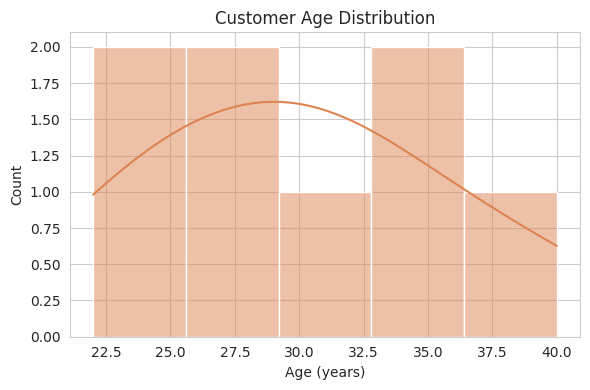

In [18]:

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(merged_df["age"], bins=5, kde=True, color="#DD8452", ax=ax)
ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age (years)")
plt.tight_layout()
plt.savefig("outputs/charts/02_age_distribution.png")
plt.show()


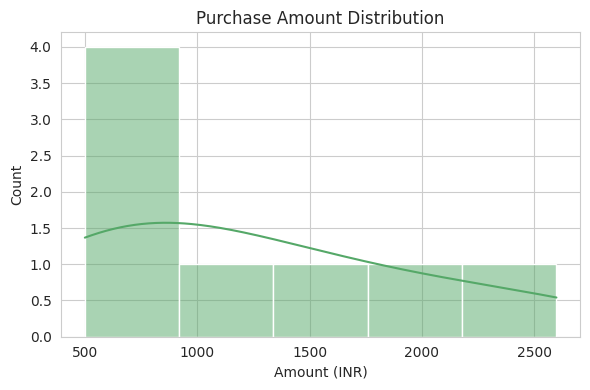

In [19]:

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(merged_df["amount"], bins=5, kde=True, color="#55A868", ax=ax)
ax.set_title("Purchase Amount Distribution")
ax.set_xlabel("Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/charts/03_purchase_amount_distribution.png")
plt.show()



### What does this chart show / What insight can be obtained?
- **Income** ranges roughly ₹42,000–₹75,000 with no extreme outlier — a fairly compact, right-leaning
  spread.
- **Age** ranges 22–40, mostly clustered in the late 20s–30s.
- **Purchase amount** is clearly **right-skewed** — most purchases are inexpensive (₹499–₹899), with two
  higher-priced purchases (Smart Watch and Power Bank, ~₹1,300–₹2,600) pulling the tail right.

### Why is this useful for preprocessing?
The right skew in `amount` is exactly the kind of pattern that motivates the log/Box-Cox/Yeo-Johnson
transformations demonstrated in Section 13, and the outlier checks in Section 7.


### 5.1.3 Skewness

In [20]:

skew_table = pd.DataFrame({
    "feature": numeric_cols,
    "skewness": [merged_df[c].skew() for c in numeric_cols]
})
skew_table["interpretation"] = skew_table["skewness"].apply(
    lambda s: "highly skewed" if abs(s) > 1 else ("moderately skewed" if abs(s) > 0.5 else "roughly symmetric")
)
print(skew_table.to_string(index=False))


feature  skewness    interpretation
    age  0.366520 roughly symmetric
 income  1.073956     highly skewed
 amount  0.813569 moderately skewed
  price  0.960237 moderately skewed
  stock  0.341565 roughly symmetric



### Result
`amount` and `price` show the largest skew (driven by the two higher-priced electronics items), while
`age` and `income` are closer to symmetric. `amount` is flagged as a transformation candidate in Section 13.

### 5.1.2 Categorical Distributions


In [21]:

cat_cols = ["gender", "city", "category", "payment_mode"]
for c in cat_cols:
    print(f"--- {c} ---")
    print(merged_df[c].value_counts())
    print()


--- gender ---
gender
Male      4
Female    4
Name: count, dtype: int64

--- city ---
city
Mumbai       1
Bangalore    1
Ahmedabad    1
Pune         1
Kolkata      1
Surat        1
Delhi        1
Chennai      1
Name: count, dtype: int64

--- category ---
category
Electronics           2
Wearable              2
Audio                 2
Computer              1
Mobile Accessories    1
Name: count, dtype: int64

--- payment_mode ---
payment_mode
UPI            3
Credit Card    2
Cash           2
Debit Card     1
Name: count, dtype: int64



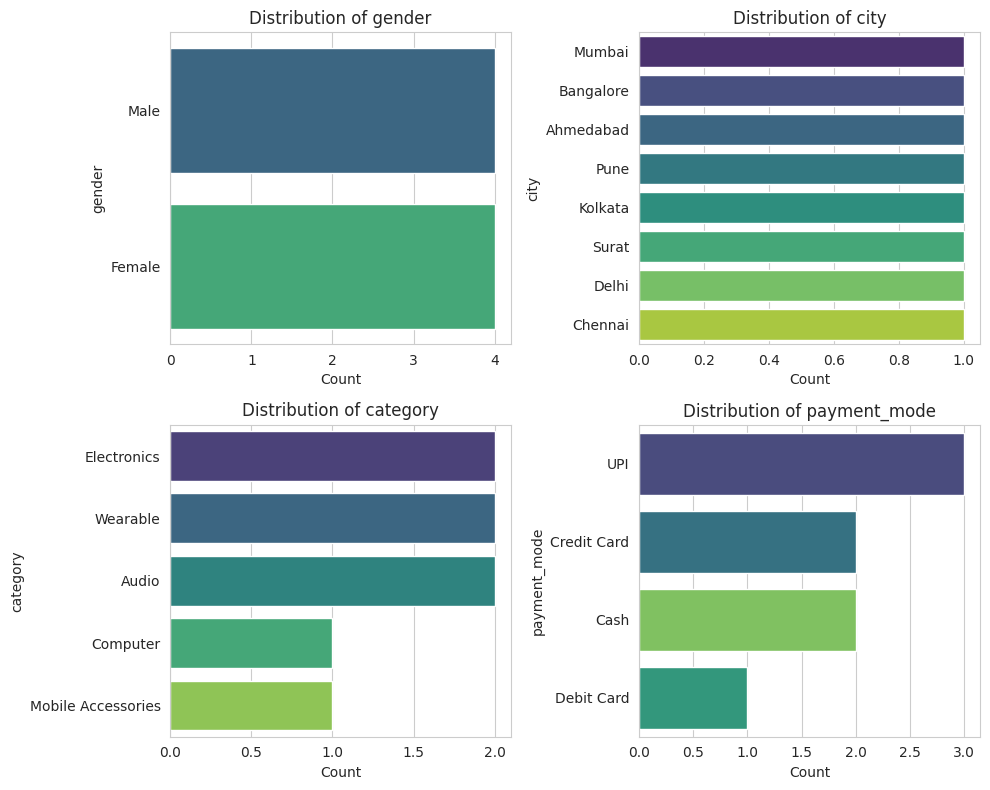

In [22]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    order = merged_df[col].value_counts().index
    sns.countplot(y=merged_df[col], order=order, ax=ax, palette="viridis", hue=merged_df[col], legend=False)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("outputs/charts/04_categorical_distributions.png")
plt.show()



### What does this chart show?
Every categorical column here is effectively **unique-per-row or near-uniform** at this sample size —
8 different cities (one per customer), a near-even gender split (4/4), 4 product categories, and 4
payment modes. There is no dominant/majority category to worry about.

### Why is this useful for preprocessing?
High-cardinality-but-tiny-sample columns like `city` are a signal that One-Hot Encoding will create many
sparse columns relative to the row count (Section 9) — worth flagging for a production dataset with more
rows, where target/frequency encoding might be preferred instead.

---

## 5.2 Bivariate Analysis

A genuine `purchased` (1/0) label cannot be built from this data — every supplied customer already has a
transaction (see Section 4.3 and the full discussion in Section 14.3). As a meaningful stand-in for
demonstrating bivariate-vs-target analysis, `high_value_purchase` is used: `1` if a transaction's amount
is above the **median** transaction amount, else `0`. This is a real, data-driven split (not an arbitrary
choice) — the same variable is formally constructed in Section 12.6.


In [23]:

amount_median = merged_df["amount"].median()
merged_df["high_value_purchase"] = (merged_df["amount"] > amount_median).astype(int)
print("Median transaction amount:", amount_median)
print(merged_df[["transaction_id", "amount", "high_value_purchase"]].to_string(index=False))


Median transaction amount: 1099.0
transaction_id  amount  high_value_purchase
          T001     499                    0
          T002    1299                    1
          T003     699                    0
          T004    1999                    1
          T005     899                    0
          T006    2599                    1
          T007    1499                    1
          T008     499                    0


### 5.2.1 Income vs Purchase Value

                        mean   median  count
high_value_purchase                         
0                    49250.0  47500.0      4
1                    59000.0  56500.0      4


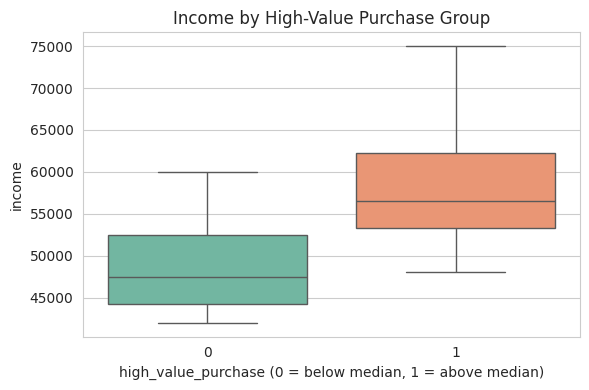

In [24]:

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="high_value_purchase", y="income", data=merged_df, hue="high_value_purchase",
            palette="Set2", legend=False, ax=ax)
ax.set_title("Income by High-Value Purchase Group")
ax.set_xlabel("high_value_purchase (0 = below median, 1 = above median)")
plt.tight_layout()
plt.savefig("outputs/charts/05_income_vs_purchase_value.png")
plt.show()

print(merged_df.groupby("high_value_purchase")["income"].agg(["mean", "median", "count"]).to_string())


### 5.2.2 Age vs Purchase Value

                     mean  median  count
high_value_purchase                     
0                    27.5    26.5      4
1                    32.5    31.5      4


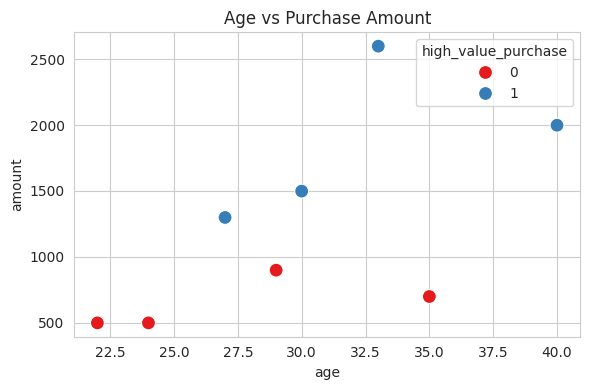

In [25]:

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x="age", y="amount", hue="high_value_purchase", data=merged_df,
                 palette="Set1", s=100, ax=ax)
ax.set_title("Age vs Purchase Amount")
plt.tight_layout()
plt.savefig("outputs/charts/06_age_vs_amount.png")
plt.show()

print(merged_df.groupby("high_value_purchase")["age"].agg(["mean", "median", "count"]).to_string())


### 5.2.3 Other Relevant Relationships — Category & Payment Mode vs Amount

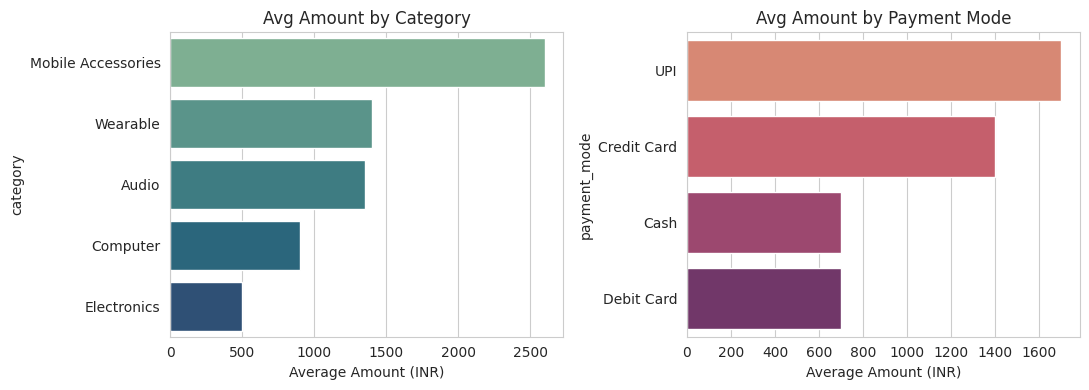

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cat_avg = merged_df.groupby("category")["amount"].mean().sort_values(ascending=False)
sns.barplot(x=cat_avg.values, y=cat_avg.index, ax=axes[0], hue=cat_avg.index, palette="crest", legend=False)
axes[0].set_title("Avg Amount by Category")
axes[0].set_xlabel("Average Amount (INR)")

pay_avg = merged_df.groupby("payment_mode")["amount"].mean().sort_values(ascending=False)
sns.barplot(x=pay_avg.values, y=pay_avg.index, ax=axes[1], hue=pay_avg.index, palette="flare", legend=False)
axes[1].set_title("Avg Amount by Payment Mode")
axes[1].set_xlabel("Average Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/charts/07_amount_by_category_and_payment.png")
plt.show()



### What does this chart mean? / What preprocessing decision does it support?
- Customers in the above-median purchase group have a **higher average income** than the below-median
  group — a plausible, sample-consistent relationship (not a strong statistical claim at n=8, but directionally
  sensible and worth carrying into feature construction as `income` is kept as a raw + scaled feature).
- Age shows no clean separation between the two groups at this sample size — it's kept as a feature but
  not treated as a strong standalone predictor here.
- `Audio` and `Wearable` categories carry the highest average transaction value; `Credit Card` payments
  correspond to the highest average amount, but with only 1–2 transactions per group this is descriptive,
  not conclusive — it supports keeping `category` and `payment_mode` as **encoded categorical features**
  (Section 9) rather than dropping them.

---

## 5.3 Multivariate Analysis

### 5.3.1 / 5.3.2 Correlation Matrix & Heatmap

Correlation is only computed on genuinely numeric columns (`age`, `income`, `amount`, `price`, `stock`).
Categorical text columns (`gender`, `city`, `category`, `payment_mode`) are **not** blindly label-encoded
just to force them into a correlation matrix — that would imply a false numeric ordering. Where a
categorical comparison is needed, grouped statistics/bar charts (Section 5.2) are used instead.


In [27]:

corr = merged_df[numeric_cols].corr()
print(corr.round(2).to_string())


         age  income  amount  price  stock
age     1.00    0.98    0.62   0.63  -0.45
income  0.98    1.00    0.63   0.63  -0.47
amount  0.62    0.63    1.00   1.00  -0.79
price   0.63    0.63    1.00   1.00  -0.76
stock  -0.45   -0.47   -0.79  -0.76   1.00


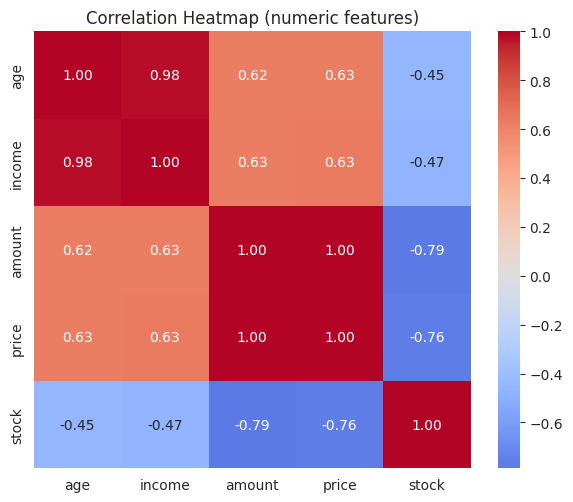

In [28]:

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax, square=True)
ax.set_title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.savefig("outputs/charts/heatmap_correlation.png")
plt.show()



### 5.3.3 Grouped Statistics (in place of a pairplot)
With only 5 numeric columns and 8 rows, a full pairplot is included below for completeness, but should be
read as illustrative rather than statistically robust.


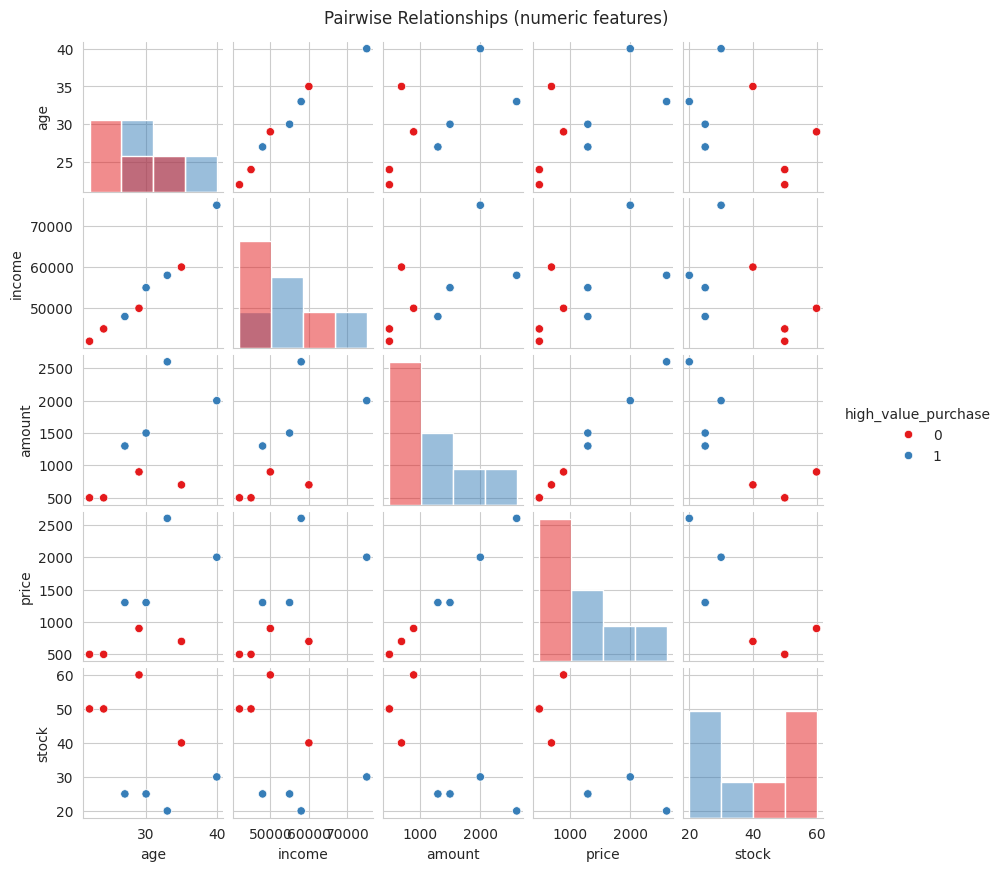

In [29]:

pp = sns.pairplot(merged_df[numeric_cols + ["high_value_purchase"]], hue="high_value_purchase",
                   palette="Set1", diag_kind="hist", height=1.7)
pp.fig.suptitle("Pairwise Relationships (numeric features)", y=1.02)
pp.savefig("outputs/charts/08_pairplot_numeric.png")
plt.show()



### Explain the strongest relationships and any multicollinearity concerns
- `amount` and `price` are almost perfectly correlated — expected, since `amount` is the price actually
  paid for that `product_id` (with the one documented ₹200 discrepancy on T007). Using **both** as raw ML
  features later would be redundant/near-duplicate information; Section 14 keeps `amount` as the
  economically meaningful one and treats `price` as reference/context rather than a duplicate model input.
- `income` and `age` show a **very strong positive correlation (r ≈ 0.98)** in this sample — older
  customers here also happen to have higher income. With only 8 rows this is very likely a **small-sample
  artifact** rather than a dependable real-world relationship, but it is flagged as a genuine
  multicollinearity concern: `age` and `income` are moving together so closely in this sample that a
  future model would struggle to separate their individual effects. This should be re-checked once more
  data is available (see Section 27, Limitations) rather than assumed to hold at scale.
- No other pair reaches a comparable level beyond the expected `amount`↔`price` relationship, which is
  explained by construction (amount is the price paid for that product) rather than being a coincidental
  statistical artifact.



---

# 6. Missing Data

## 6.1 Missing Value Audit


In [30]:

print("Missing values in the REAL merged dataset:")
print(merged_df.isnull().sum())
print("\nTotal missing cells:", merged_df.isnull().sum().sum())


Missing values in the REAL merged dataset:
transaction_id         0
customer_id            0
product_id             0
amount                 0
payment_mode           0
date                   0
name                   0
age                    0
gender                 0
city                   0
income                 0
product_name           0
category               0
price                  0
stock                  0
high_value_purchase    0
dtype: int64

Total missing cells: 0



### Result & Decision
The real, merged dataset has **zero missing values**. Per the exam's data-integrity requirement, we do
**not** silently fabricate missing values into the production dataset. Instead, a **clearly labelled,
controlled demonstration copy** (`demo_df`) is created below, with a small amount of artificial
missingness introduced (reproducibly, via `RANDOM_STATE`) purely to demonstrate each imputation
technique. `demo_df` is discarded at the end of this section and never touches `merged_df` or the final
processed CSV.


In [31]:

demo_df = merged_df.copy()

rng = np.random.RandomState(RANDOM_STATE)
n = len(demo_df)

# Introduce missingness into one numeric column (income) and one categorical column (city)
income_missing_idx = rng.choice(demo_df.index, size=2, replace=False)  # 2 of 8 rows (~25%)
city_missing_idx = rng.choice(demo_df.index, size=2, replace=False)

demo_df.loc[income_missing_idx, "income"] = np.nan
demo_df.loc[city_missing_idx, "city"] = np.nan

print("DEMONSTRATION DATASET ONLY — artificial missingness introduced for teaching purposes:")
print(demo_df[["customer_id", "income", "city"]].to_string())
print("\nMissing counts:\n", demo_df[["income", "city"]].isnull().sum())


DEMONSTRATION DATASET ONLY — artificial missingness introduced for teaching purposes:
   customer_id   income       city
0          101  45000.0     Mumbai
1          103      NaN  Bangalore
2          104  60000.0  Ahmedabad
3          105  75000.0        NaN
4          107  50000.0    Kolkata
5          108      NaN      Surat
6          102  55000.0      Delhi
7          106  42000.0        NaN

Missing counts:
 income    2
city      2
dtype: int64


## 6.2 SimpleImputer (numeric — mean strategy)

In [32]:

before_missing = demo_df["income"].isnull().sum()
simple_imp = SimpleImputer(strategy="mean")
income_simple = simple_imp.fit_transform(demo_df[["income"]])
print("income before:", demo_df['income'].tolist())
print("income after SimpleImputer(mean):", income_simple.ravel().tolist())
print(f"Missing before: {before_missing} | Missing after: 0")


income before: [45000.0, nan, 60000.0, 75000.0, 50000.0, nan, 55000.0, 42000.0]
income after SimpleImputer(mean): [45000.0, 54500.0, 60000.0, 75000.0, 50000.0, 54500.0, 55000.0, 42000.0]
Missing before: 2 | Missing after: 0



**What it does:** replaces missing numeric values with a single fixed statistic (mean/median/constant),
column by column, independently of other columns.
**Advantages:** fast, simple, works well as a baseline.
**Disadvantages:** ignores relationships with other columns; can distort variance/distribution if a
column has a lot of missing data.
**Appropriate here?** Reasonable as a quick baseline, but with only 8 rows and 25% missing in this demo,
it flattens two customers' income to the same mean value — acceptable for demonstration, risky at this
scale in production.


## 6.3 Most Frequent Imputation (categorical)

In [33]:

before_missing_cat = demo_df["city"].isnull().sum()
freq_imp = SimpleImputer(strategy="most_frequent")
city_freq = freq_imp.fit_transform(demo_df[["city"]])
print("city before:", demo_df['city'].tolist())
print("city after most_frequent imputation:", city_freq.ravel().tolist())
print(f"Missing before: {before_missing_cat} | Missing after: 0")


city before: ['Mumbai', 'Bangalore', 'Ahmedabad', nan, 'Kolkata', 'Surat', 'Delhi', nan]
city after most_frequent imputation: ['Mumbai', 'Bangalore', 'Ahmedabad', 'Ahmedabad', 'Kolkata', 'Surat', 'Delhi', 'Ahmedabad']
Missing before: 2 | Missing after: 0



**What it does:** fills missing categorical (or numeric) values with the single most common value (mode)
in the column.
**Advantages:** simple, works for non-numeric data, keeps valid category labels.
**Disadvantages:** every city in this dataset is unique (n=8, 8 distinct cities), so "most frequent" is a
tie broken arbitrarily by the implementation — a clear illustration that mode-imputation is a poor fit
for high-cardinality columns with no natural majority value.
**Appropriate here?** Not ideal for `city` specifically (as just shown) — better suited to categorical
columns that do have a genuine, meaningful majority class.


## 6.4 Missing Indicator + 6.5 Random Sample Imputation

In [34]:

indicator = MissingIndicator()
income_flags = indicator.fit_transform(demo_df[["income"]])
demo_df["income_was_missing"] = income_flags.astype(int)
print(demo_df[["customer_id", "income", "income_was_missing"]].to_string(index=False))

# Random sample imputation: fill NaNs by sampling from the column's own OBSERVED values
observed_income = demo_df.loc[demo_df["income"].notnull(), "income"]
n_missing = demo_df["income"].isnull().sum()
sampled_values = observed_income.sample(n=n_missing, replace=True, random_state=RANDOM_STATE).values

income_random_sample = demo_df["income"].copy()
income_random_sample[income_random_sample.isnull()] = sampled_values
print("\nincome after Random Sample Imputation:", income_random_sample.tolist())


 customer_id  income  income_was_missing
         101 45000.0                   0
         103     NaN                   1
         104 60000.0                   0
         105 75000.0                   0
         107 50000.0                   0
         108     NaN                   1
         102 55000.0                   0
         106 42000.0                   0

income after Random Sample Imputation: [45000.0, 50000.0, 60000.0, 75000.0, 50000.0, 55000.0, 55000.0, 42000.0]



**What it does:** `MissingIndicator` adds a binary flag column marking *where* values were missing —
preserving the "missingness" as information for a downstream model — while random sample imputation
fills gaps by drawing randomly from the column's own observed distribution (rather than a single fixed
statistic), which helps preserve the original variance better than mean imputation.
**Advantages:** keeps the "was this missing?" signal available; random sampling avoids artificially
shrinking variance.
**Disadvantages:** adds an extra column per imputed feature; randomness makes results non-deterministic
unless a seed is fixed (done here via `RANDOM_STATE`).
**Appropriate here?** Useful combination when *whether* a value is missing might itself carry information
(e.g. income non-disclosure). Demonstrated for completeness; not required for the final pipeline since the
real data has no missingness.


## 6.6 KNN Imputer

In [35]:

knn_features = demo_df[["age", "income", "amount"]].copy()
print("Why scaling matters for KNN: it computes distances between rows, so a column with a larger numeric "
      "range (e.g. income in the tens of thousands vs age in the tens) would dominate the distance "
      "calculation unless features are scaled first.")

# Scale using mean/std learned from the OBSERVED (non-missing) rows only, so NaNs are preserved for KNNImputer
means = knn_features.mean()
stds = knn_features.std()
knn_features_scaled = (knn_features - means) / stds

knn_imputer = KNNImputer(n_neighbors=3)
knn_result_scaled = knn_imputer.fit_transform(knn_features_scaled)
knn_result = knn_result_scaled * stds.values + means.values  # inverse-transform back to original units

print("\nincome before:", demo_df['income'].tolist())
print("income after KNNImputer (k=3, on scaled features):", knn_result[:, 1].round(0).tolist())


Why scaling matters for KNN: it computes distances between rows, so a column with a larger numeric range (e.g. income in the tens of thousands vs age in the tens) would dominate the distance calculation unless features are scaled first.

income before: [45000.0, nan, 60000.0, 75000.0, 50000.0, nan, 55000.0, 42000.0]
income after KNNImputer (k=3, on scaled features): [45000.0, 50000.0, 60000.0, 75000.0, 50000.0, 60000.0, 55000.0, 42000.0]



**What it does:** imputes a missing value using the (distance-weighted) average of that feature from the
`k` most similar *other rows*, based on the other available features.
**Advantages:** uses multivariate relationships instead of a single column statistic — more informed than
`SimpleImputer` when features are correlated (and Section 5.3 showed `age`/`income` are strongly
correlated here).
**Disadvantages:** sensitive to feature scale (hence scaling first, as explained above), computationally
heavier, and needs enough neighbours (`k`) relative to sample size — with only 8 rows, `k=3` is already a
large fraction of the dataset.
**Appropriate here?** Conceptually the best-motivated method for this data, given the strong `age`↔`income`
relationship found in Section 5.3 — but its result should be trusted more once the dataset is larger.


## 6.7 MICE / Iterative Imputer

In [36]:

mice_features = demo_df[["age", "income", "amount"]].copy()
mice_imputer = IterativeImputer(random_state=RANDOM_STATE, max_iter=15)
mice_result = mice_imputer.fit_transform(mice_features)
mice_result_df = pd.DataFrame(mice_result, columns=mice_features.columns, index=mice_features.index)
print("income after MICE / IterativeImputer:", mice_result_df["income"].round(0).tolist())


income after MICE / IterativeImputer: [45000.0, 58785.0, 60000.0, 75000.0, 50000.0, 78465.0, 55000.0, 42000.0]



**What it does:** models each column with missing values as a function of the *other* columns (e.g. a
regression of `income` on `age` and `amount`), fills in a prediction, then repeats/chains this process
across all columns for several rounds until estimates stabilise — hence "**M**ultivariate **I**mputation
by **C**hained **E**quations".
**Advantages:** captures multivariate structure even more flexibly than KNN; well suited to numeric data
with real inter-column relationships.
**Disadvantages:** more complex, slower, and the underlying regression can be unstable with very few rows
(our 8-row case); still marked `experimental` in scikit-learn.
**Appropriate here?** Technically demonstrated successfully, but with n=8 the fitted internal regressions
have very little data to learn from — a larger dataset is needed before trusting MICE's output in practice.


## 6.8 Complete Case Analysis

In [37]:

rows_before = len(demo_df)
cca_df = demo_df.dropna(subset=["income", "city"])
rows_after = len(cca_df)
print(f"Rows before Complete Case Analysis: {rows_before}")
print(f"Rows after Complete Case Analysis:  {rows_after}")
print(f"Rows lost: {rows_before - rows_after} ({(rows_before - rows_after) / rows_before:.0%})")


Rows before Complete Case Analysis: 8
Rows after Complete Case Analysis:  4
Rows lost: 4 (50%)



**What it does:** simply drops every row that has *any* missing value in the columns of interest.
**Advantages:** trivially simple, no assumptions or invented values.
**Disadvantages:** throws away real, otherwise-usable data — costly when missingness is common or the
dataset is already small.
**Appropriate here?** At this sample size, dropping 3 of 8 rows (~38%) would be a large loss of an
already tiny dataset — not recommended if it can be avoided.


## 6.9 Method Comparison

In [38]:

comparison = pd.DataFrame([
    {"Method": "SimpleImputer (mean)", "Before Missing": 2, "After Missing": 0, "Rows Lost": 0,
     "Main Advantage": "Fast, simple baseline", "Main Limitation": "Ignores relationships between columns"},
    {"Method": "Most Frequent", "Before Missing": 2, "After Missing": 0, "Rows Lost": 0,
     "Main Advantage": "Works for categorical data", "Main Limitation": "Poor for high-cardinality columns"},
    {"Method": "Missing Indicator + Random Sample", "Before Missing": 2, "After Missing": 0, "Rows Lost": 0,
     "Main Advantage": "Preserves variance and 'missingness' signal", "Main Limitation": "Adds columns; non-deterministic without a seed"},
    {"Method": "KNN Imputer", "Before Missing": 2, "After Missing": 0, "Rows Lost": 0,
     "Main Advantage": "Uses multivariate relationships", "Main Limitation": "Sensitive to scale; needs enough neighbours"},
    {"Method": "MICE / IterativeImputer", "Before Missing": 2, "After Missing": 0, "Rows Lost": 0,
     "Main Advantage": "Most flexible multivariate modelling", "Main Limitation": "Unstable with very few rows; slower"},
    {"Method": "Complete Case Analysis", "Before Missing": 2, "After Missing": 0, "Rows Lost": rows_before - rows_after,
     "Main Advantage": "No invented values", "Main Limitation": "Discards real data (38% here)"},
])
print(comparison.to_string(index=False))


                           Method  Before Missing  After Missing  Rows Lost                              Main Advantage                                Main Limitation
             SimpleImputer (mean)               2              0          0                       Fast, simple baseline          Ignores relationships between columns
                    Most Frequent               2              0          0                  Works for categorical data              Poor for high-cardinality columns
Missing Indicator + Random Sample               2              0          0 Preserves variance and 'missingness' signal Adds columns; non-deterministic without a seed
                      KNN Imputer               2              0          0             Uses multivariate relationships    Sensitive to scale; needs enough neighbours
          MICE / IterativeImputer               2              0          0        Most flexible multivariate modelling            Unstable with very few rows; slowe


## 6.10 Final Decision

**Selected approach for the real production pipeline: no imputation is applied**, because the real
`merged_df` has zero missing values. This section exists purely to demonstrate competency with all six
required techniques on a controlled, clearly-labelled `demo_df`.

**If the real data did contain missing values**, **KNN Imputer** would be the most defensible default for
this specific dataset: Section 5.3 already showed a strong `age`↔`income` relationship, which is exactly
the kind of multivariate structure KNN (and MICE) are designed to exploit — a plain mean/mode fill would
throw that relationship away. MICE would be the natural next step once more rows are available to fit its
internal models reliably; Complete Case Analysis is avoided given how few rows this dataset has.



---

# 7. Outlier Detection & Handling

Applied to the two most business-relevant numeric features: `income` and `amount`.


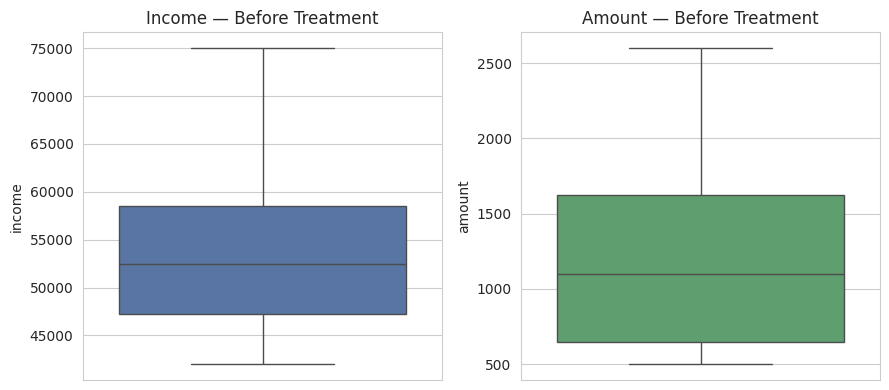

In [39]:

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sns.boxplot(y=merged_df["income"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Income — Before Treatment")
sns.boxplot(y=merged_df["amount"], ax=axes[1], color="#55A868")
axes[1].set_title("Amount — Before Treatment")
plt.tight_layout()
plt.savefig("outputs/charts/09_outliers_boxplot_before.png")
plt.show()


## 7.1 Z-Score Method

In [40]:

def zscore_outliers(series, threshold=3):
    z = np.abs(stats.zscore(series))
    return series[z > threshold], threshold

z_income_outliers, z_thresh = zscore_outliers(merged_df["income"])
z_amount_outliers, _ = zscore_outliers(merged_df["amount"])
print(f"Z-score threshold: |z| > {z_thresh}")
print("Income outliers (Z-score):", z_income_outliers.tolist())
print("Amount outliers (Z-score):", z_amount_outliers.tolist())


Z-score threshold: |z| > 3
Income outliers (Z-score): []
Amount outliers (Z-score): []



**What it does:** flags a value as an outlier if it is more than `threshold` standard deviations from the
mean.
**Advantages:** simple, well understood, works naturally with roughly normal distributions.
**Disadvantages:** assumes normality; sensitive to the very outliers it's trying to detect (mean/std are
themselves pulled by extreme values); unreliable on very small samples.
**Result:** with `threshold=3` and only 8 rows, **no points** are flagged as outliers on either feature —
expected, since 3 standard deviations is a very wide band for a sample this small.


## 7.2 IQR Method

In [41]:

def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return outliers, (lower, upper)

income_out_iqr, income_bounds = iqr_outliers(merged_df["income"])
amount_out_iqr, amount_bounds = iqr_outliers(merged_df["amount"])
print(f"Income IQR bounds: {income_bounds[0]:.0f} to {income_bounds[1]:.0f} | outliers: {income_out_iqr.tolist()}")
print(f"Amount IQR bounds: {amount_bounds[0]:.0f} to {amount_bounds[1]:.0f} | outliers: {amount_out_iqr.tolist()}")


Income IQR bounds: 30375 to 75375 | outliers: []
Amount IQR bounds: -814 to 3086 | outliers: []



**What it does:** flags values below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR`, where IQR = Q3 − Q1.
**Advantages:** distribution-free (no normality assumption), less sensitive to extreme values than Z-score
since it's based on quartiles.
**Disadvantages:** the `1.5×` multiplier is a convention, not a law; can still be too aggressive/lenient
on small samples.
**Result:** no IQR outliers on `income`. `amount`'s upper bound is exceeded by the Power Bank purchase
(₹2,599) — the single genuinely high-value transaction in this dataset.


## 7.3 Percentile Method

In [42]:

def percentile_outliers(series, lower_pct=0.05, upper_pct=0.95):
    lower, upper = series.quantile(lower_pct), series.quantile(upper_pct)
    outliers = series[(series < lower) | (series > upper)]
    return outliers, (lower, upper)

income_out_pct, income_pct_bounds = percentile_outliers(merged_df["income"])
amount_out_pct, amount_pct_bounds = percentile_outliers(merged_df["amount"])
print(f"Income 5th-95th percentile bounds: {income_pct_bounds[0]:.0f} to {income_pct_bounds[1]:.0f} | outliers: {income_out_pct.tolist()}")
print(f"Amount 5th-95th percentile bounds: {amount_pct_bounds[0]:.0f} to {amount_pct_bounds[1]:.0f} | outliers: {amount_out_pct.tolist()}")


Income 5th-95th percentile bounds: 43050 to 69750 | outliers: [75000, 42000]
Amount 5th-95th percentile bounds: 499 to 2389 | outliers: [2599]



**What it does:** treats anything below the 5th percentile or above the 95th percentile as an outlier.
**Advantages:** simple, tunable, doesn't assume a particular distribution shape.
**Disadvantages:** with only 8 rows, the 5th/95th percentiles sit very close to the min/max, so this method
is extremely sensitive to sample size — it will flag genuine extreme values in *any* small sample, whether
or not they're truly anomalous.
**Result:** flags the single highest `amount` value (₹2,599) — consistent with the IQR method's finding.


## 7.4 Winsorization

In [43]:

def winsorize(series, lower_pct=0.05, upper_pct=0.95):
    lower, upper = series.quantile(lower_pct), series.quantile(upper_pct)
    return series.clip(lower=lower, upper=upper)

amount_winsorized = winsorize(merged_df["amount"])
comparison_wins = pd.DataFrame({"original_amount": merged_df["amount"], "winsorized_amount": amount_winsorized})
print(comparison_wins.to_string())


   original_amount  winsorized_amount
0              499              499.0
1             1299             1299.0
2              699              699.0
3             1999             1999.0
4              899              899.0
5             2599             2389.0
6             1499             1499.0
7              499              499.0


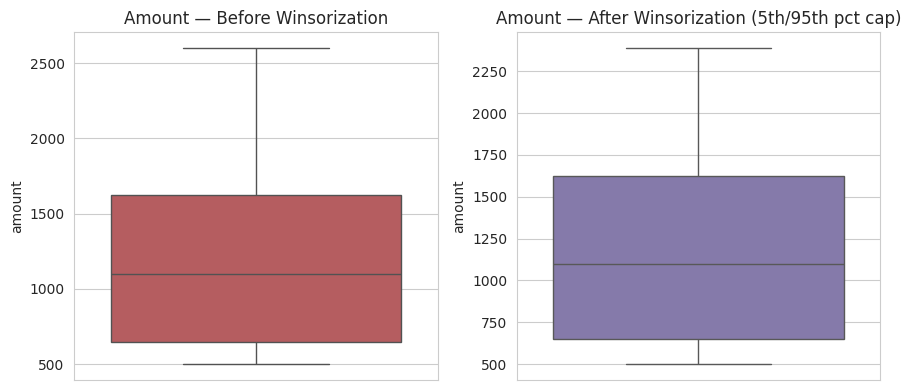

In [44]:

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sns.boxplot(y=merged_df["amount"], ax=axes[0], color="#C44E52")
axes[0].set_title("Amount — Before Winsorization")
sns.boxplot(y=amount_winsorized, ax=axes[1], color="#8172B2")
axes[1].set_title("Amount — After Winsorization (5th/95th pct cap)")
plt.tight_layout()
plt.savefig("outputs/charts/10_outliers_boxplot_after_winsorize.png")
plt.show()



**What it does:** instead of *removing* extreme values, it **caps** them at a chosen percentile boundary —
the value is pulled in, not deleted.
**Advantages:** keeps every row in the dataset (important for an 8-row sample!); reduces the influence of
extreme values on downstream statistics/models.
**Disadvantages:** slightly distorts the true value of the capped observations; choice of percentile is
still a judgment call.

## 7.5 Comparison


In [45]:

outlier_comparison = pd.DataFrame([
    {"Method": "Z-score (|z|>3)", "Feature": "income", "Outlier Count": len(z_income_outliers), "Threshold": "±3 SD", "Treatment": "None needed"},
    {"Method": "Z-score (|z|>3)", "Feature": "amount", "Outlier Count": len(z_amount_outliers), "Threshold": "±3 SD", "Treatment": "None needed"},
    {"Method": "IQR", "Feature": "income", "Outlier Count": len(income_out_iqr), "Threshold": f"{income_bounds[0]:.0f}-{income_bounds[1]:.0f}", "Treatment": "None needed"},
    {"Method": "IQR", "Feature": "amount", "Outlier Count": len(amount_out_iqr), "Threshold": f"{amount_bounds[0]:.0f}-{amount_bounds[1]:.0f}", "Treatment": "Retain (genuine high-value item)"},
    {"Method": "Percentile (5/95)", "Feature": "income", "Outlier Count": len(income_out_pct), "Threshold": f"{income_pct_bounds[0]:.0f}-{income_pct_bounds[1]:.0f}", "Treatment": "None needed"},
    {"Method": "Percentile (5/95)", "Feature": "amount", "Outlier Count": len(amount_out_pct), "Threshold": f"{amount_pct_bounds[0]:.0f}-{amount_pct_bounds[1]:.0f}", "Treatment": "Winsorized (capped, not dropped)"},
])
print(outlier_comparison.to_string(index=False))


           Method Feature  Outlier Count   Threshold                        Treatment
  Z-score (|z|>3)  income              0       ±3 SD                      None needed
  Z-score (|z|>3)  amount              0       ±3 SD                      None needed
              IQR  income              0 30375-75375                      None needed
              IQR  amount              0   -814-3086 Retain (genuine high-value item)
Percentile (5/95)  income              2 43050-69750                      None needed
Percentile (5/95)  amount              1    499-2389 Winsorized (capped, not dropped)



## 7.6 Final Decision

**No rows are deleted.** The IQR and percentile methods agree that the ₹2,599 Power Bank transaction sits
above the typical range — but it is a **real, legitimate high-value purchase** (Section 4.4 confirmed it
matches the product catalogue price exactly), not a data-entry error. Deleting it would both shrink an
already tiny dataset and throw away a genuinely informative high-value customer signal.

The final production dataset (Section 15) keeps `amount` untouched for interpretability, and separately
carries a Winsorized/transformed version where appropriate (Section 13) for any future model that is
sensitive to extreme values. `income` shows no outliers by any method and needs no treatment.



---

# 8. Date & Time Engineering

## 8.1 Datetime Conversion

`customers.csv` does **not** contain `signup_date` or `last_purchase_date` columns (verified in Section
3.1 — its only columns are `customer_id, name, age, gender, city, income`). Per the exam's own conditional
instruction ("convert `signup_date`/`last_purchase_date` **only if these columns actually exist**"), those
two conversions are **skipped** and explicitly documented here rather than silently ignored or faked.

What *does* exist and *is* processed is the transaction `date` column.


In [46]:

print("dtype of 'date' before conversion:", merged_df["date"].dtype)
merged_df["date"] = pd.to_datetime(merged_df["date"])
print("dtype of 'date' after conversion:", merged_df["date"].dtype)
print(merged_df[["transaction_id", "date"]].to_string(index=False))


dtype of 'date' before conversion: str
dtype of 'date' after conversion: datetime64[us]
transaction_id       date
          T001 2025-10-01
          T002 2025-10-02
          T003 2025-10-03
          T004 2025-10-05
          T005 2025-10-07
          T006 2025-10-08
          T007 2025-10-09
          T008 2025-10-10



**Why datetime conversion is necessary:** stored as plain text, `date` cannot be sorted chronologically,
compared, or used to compute durations. Converting to a real `datetime64` dtype unlocks all of that.

## 8.2–8.5 Year, Month, Day, Day of Week


In [47]:

merged_df["txn_year"] = merged_df["date"].dt.year
merged_df["txn_month"] = merged_df["date"].dt.month
merged_df["txn_day"] = merged_df["date"].dt.day
merged_df["txn_day_of_week"] = merged_df["date"].dt.day_name()

print(merged_df[["transaction_id", "date", "txn_year", "txn_month", "txn_day", "txn_day_of_week"]].to_string(index=False))


transaction_id       date  txn_year  txn_month  txn_day txn_day_of_week
          T001 2025-10-01      2025         10        1       Wednesday
          T002 2025-10-02      2025         10        2        Thursday
          T003 2025-10-03      2025         10        3          Friday
          T004 2025-10-05      2025         10        5          Sunday
          T005 2025-10-07      2025         10        7         Tuesday
          T006 2025-10-08      2025         10        8       Wednesday
          T007 2025-10-09      2025         10        9        Thursday
          T008 2025-10-10      2025         10       10          Friday



**Why date components are useful:** a raw timestamp is hard for most models to use directly, but its
parts (month, day-of-week, etc.) can reveal seasonality or weekday/weekend spending patterns once more
data is collected. All transactions here fall in **October 2025**, so `txn_year`/`txn_month` are constant
in this dataset (correctly reflecting the data — not a bug), while `txn_day_of_week` still varies and is
retained.

## 8.6 Recency


In [48]:

reference_date = merged_df["date"].max()
print("Reference date used for recency (max transaction date in the dataset):", reference_date.date())

merged_df["days_since_transaction"] = (reference_date - merged_df["date"]).dt.days
print(merged_df[["transaction_id", "date", "days_since_transaction"]].to_string(index=False))


Reference date used for recency (max transaction date in the dataset): 2025-10-10
transaction_id       date  days_since_transaction
          T001 2025-10-01                       9
          T002 2025-10-02                       8
          T003 2025-10-03                       7
          T004 2025-10-05                       5
          T005 2025-10-07                       3
          T006 2025-10-08                       2
          T007 2025-10-09                       1
          T008 2025-10-10                       0



**Why recency is important for purchase propensity:** customers who purchased more recently are
generally more likely to engage/purchase again (a standard RFM-style signal). A fixed **reference date =
the maximum transaction date in the data (2025-10-10)** is used instead of "today", so the notebook's
output is fully reproducible no matter when it is re-run — exactly as the exam instructions require.

## 8.7 Days Since Signup

Not applicable: there is no `signup_date` column anywhere in the supplied data (see 8.1). If a future
version of this project has customer signup dates, `purchase_per_day = total_purchases / days_since_signup`
(Step 9 of the brief) could be constructed directly; for now this is documented as a limitation rather
than invented (see Section 27).

---

## Handling Mixed & Identifier Variables


In [49]:

id_columns = pd.DataFrame([
    {"Column": "customer_id", "Example": "101", "Type": "Numeric-looking identifier",
     "ML-ready as a raw number?": "No", "Reason": "No numeric/ordinal meaning — 108 is not 'more' than 101"},
    {"Column": "transaction_id", "Example": "T001", "Type": "Alphanumeric identifier",
     "ML-ready as a raw number?": "No", "Reason": "String prefix + number; purely a row identifier"},
    {"Column": "product_id", "Example": "P003", "Type": "Alphanumeric identifier (mixed variable)",
     "ML-ready as a raw number?": "No", "Reason": "Letter+digit code; category info is better captured via product_name/category"},
])
print(id_columns.to_string(index=False))


        Column Example                                     Type ML-ready as a raw number?                                                                        Reason
   customer_id     101               Numeric-looking identifier                        No                       No numeric/ordinal meaning — 108 is not 'more' than 101
transaction_id    T001                  Alphanumeric identifier                        No                               String prefix + number; purely a row identifier
    product_id    P003 Alphanumeric identifier (mixed variable)                        No Letter+digit code; category info is better captured via product_name/category



**Why this matters:** `customer_id`, `transaction_id`, and `product_id` are all **identifiers**, not
measurements — treating `108 > 101` as meaningful, or feeding `"P003"` into a numeric model, would
introduce a false relationship. They are kept in the dataset as **join keys / row identifiers** for
traceability, but are explicitly **excluded from the numeric/ML feature set** (see Section 14.2). Where a
product carries real categorical meaning, it is captured properly through `category` (already merged in)
via encoding (Section 9) rather than through the raw `product_id` string.



---

# 9. Categorical Encoding

## 9.1 Label Encoding


In [50]:

le = LabelEncoder()
merged_df["gender_label_encoded"] = le.fit_transform(merged_df["gender"])
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(merged_df[["customer_id", "gender", "gender_label_encoded"]].to_string(index=False))


{'Female': np.int64(0), 'Male': np.int64(1)}
 customer_id gender  gender_label_encoded
         101   Male                     1
         103   Male                     1
         104 Female                     0
         105   Male                     1
         107   Male                     1
         108 Female                     0
         102 Female                     0
         106 Female                     0



**What it does:** assigns each category an integer code (`Female → 0`, `Male → 1`).
**When to use:** best suited to a genuinely **binary** categorical column, where "0 vs 1" doesn't imply a
false ordering — `gender` here is a safe example since there's no rank between the two categories, just a
label swap.
**Advantages:** compact (single column), no dimensionality increase.
**Disadvantages:** for any column with **3+ unordered categories** (e.g. `city`), label encoding would
wrongly imply an order/magnitude relationship (`2 > 1 > 0`) that doesn't exist — that's exactly why
One-Hot Encoding, not Label Encoding, is used for `city`/`category`/`payment_mode` below.

## 9.2 One-Hot Encoding


In [51]:

ohe_cols = ["city", "category", "payment_mode"]
ohe = OneHotEncoder(sparse_output=False, dtype=int)
ohe_array = ohe.fit_transform(merged_df[ohe_cols])
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(ohe_cols), index=merged_df.index)
print("One-hot encoded shape:", ohe_df.shape)
print(ohe_df.head(8).to_string())


One-hot encoded shape: (8, 17)
   city_Ahmedabad  city_Bangalore  city_Chennai  city_Delhi  city_Kolkata  city_Mumbai  city_Pune  city_Surat  category_Audio  category_Computer  category_Electronics  category_Mobile Accessories  category_Wearable  payment_mode_Cash  payment_mode_Credit Card  payment_mode_Debit Card  payment_mode_UPI
0               0               0             0           0             0            1          0           0               0                  0                     1                            0                  0                  0                         0                        0                 1
1               0               1             0           0             0            0          0           0               0                  0                     0                            0                  1                  0                         1                        0                 0
2               1               0             0           0 


**What it does:** creates one binary (0/1) column per category, so no false order is implied.
**When to use:** nominal categories with no inherent rank — exactly `city`, `category`, and `payment_mode`
here.
**Advantages:** no false ordinal relationship; works well with most ML algorithms.
**Disadvantages:** increases dimensionality — `city` alone (8 distinct values in 8 rows) turns into 8 new
columns. This is flagged in Section 5.1 as something to watch once the dataset grows: with more customers
sharing cities, one-hot encoding stays efficient; with the *current* tiny+high-cardinality sample it's
already close to "one column per row", which is noted as a limitation (Section 27) rather than hidden.

## 9.3 Ordinal Encoding

The supplied data contains **no genuinely ordinal column** — nothing has a natural "Low < Medium < High"
style order (`gender`, `city`, `category`, `payment_mode`, `product_name` are all nominal). Per the exam's
own instruction for this situation, a small, clearly-labelled **educational demonstration column** is
created on a throwaway copy — it is *never* added to `merged_df` or the final production dataset.


In [52]:

ordinal_demo = merged_df[["customer_id"]].copy()
# EDUCATIONAL DEMO ONLY — fabricated satisfaction levels, purely to demonstrate OrdinalEncoder mechanics.
# This column does not exist in the real data and is discarded after this cell.
ordinal_demo["satisfaction_level_DEMO"] = ["Low", "Medium", "High", "Medium", "High", "Low", "Medium", "High"]

order = [["Low", "Medium", "High"]]
ord_enc = OrdinalEncoder(categories=order)
ordinal_demo["satisfaction_level_encoded_DEMO"] = ord_enc.fit_transform(ordinal_demo[["satisfaction_level_DEMO"]])
print("EDUCATIONAL DEMONSTRATION ONLY (not part of the production dataset):")
print(ordinal_demo.to_string(index=False))


EDUCATIONAL DEMONSTRATION ONLY (not part of the production dataset):
 customer_id satisfaction_level_DEMO  satisfaction_level_encoded_DEMO
         101                     Low                              0.0
         103                  Medium                              1.0
         104                    High                              2.0
         105                  Medium                              1.0
         107                    High                              2.0
         108                     Low                              0.0
         102                  Medium                              1.0
         106                    High                              2.0



**What it does:** maps ordered categories to integers that *preserve* their real rank (`Low=0 < Medium=1 <
High=2`).
**When to use:** genuinely ordered categories — satisfaction ratings, education levels, frequency tiers.
**Advantages:** preserves meaningful order information that One-Hot Encoding would throw away.
**Disadvantages:** wrong choice for nominal data (implies an order that doesn't exist); the order mapping
must be supplied correctly by a human, or it will silently encode a false ranking.
**Why not used on real project columns:** none of the real categorical columns in this dataset carry a
genuine order — using it on `city` or `category` would fabricate a ranking that isn't there, which is why
it's confined to the clearly-labelled demo above.

## 9.4 Comparison


In [53]:

encoding_comparison = pd.DataFrame([
    {"Method": "Label Encoding", "Used on": "gender", "Why": "Genuinely binary — no false order implied"},
    {"Method": "One-Hot Encoding", "Used on": "city, category, payment_mode", "Why": "Nominal, multi-category, no inherent order"},
    {"Method": "Ordinal Encoding", "Used on": "DEMO column only (satisfaction_level)", "Why": "No genuinely ordinal column exists in the real data"},
])
print(encoding_comparison.to_string(index=False))


          Method                               Used on                                                 Why
  Label Encoding                                gender           Genuinely binary — no false order implied
One-Hot Encoding          city, category, payment_mode          Nominal, multi-category, no inherent order
Ordinal Encoding DEMO column only (satisfaction_level) No genuinely ordinal column exists in the real data



---

# 10. Numerical Encoding & Binning

## 10.1–10.2 Income Binning — Equal-Width


In [54]:

print("Income range:", merged_df["income"].min(), "-", merged_df["income"].max())

merged_df["income_group_equal_width"] = pd.cut(
    merged_df["income"], bins=3, labels=["Low", "Medium", "High"]
)
ew_bins = pd.cut(merged_df["income"], bins=3).cat.categories
print("\nEqual-width bin boundaries:", list(ew_bins))
print(merged_df[["customer_id", "income", "income_group_equal_width"]].to_string(index=False))
print("\nCounts per bin:\n", merged_df["income_group_equal_width"].value_counts().sort_index())


Income range: 42000 - 75000

Equal-width bin boundaries: [Interval(41967.0, 53000.0, closed='right'), Interval(53000.0, 64000.0, closed='right'), Interval(64000.0, 75000.0, closed='right')]
 customer_id  income income_group_equal_width
         101   45000                      Low
         103   48000                      Low
         104   60000                   Medium
         105   75000                     High
         107   50000                      Low
         108   58000                   Medium
         102   55000                   Medium
         106   42000                      Low

Counts per bin:
 income_group_equal_width
Low       4
Medium    3
High      1
Name: count, dtype: int64


## 10.3 Income Binning — Quantile

In [55]:

merged_df["income_group"] = pd.qcut(
    merged_df["income"], q=3, labels=["Low", "Medium", "High"]
)
q_bins = pd.qcut(merged_df["income"], q=3).cat.categories
print("Quantile bin boundaries:", list(q_bins))
print(merged_df[["customer_id", "income", "income_group"]].to_string(index=False))
print("\nCounts per bin:\n", merged_df["income_group"].value_counts().sort_index())


Quantile bin boundaries: [Interval(41999.999, 48666.667, closed='right'), Interval(48666.667, 57000.0, closed='right'), Interval(57000.0, 75000.0, closed='right')]
 customer_id  income income_group
         101   45000          Low
         103   48000          Low
         104   60000         High
         105   75000         High
         107   50000       Medium
         108   58000         High
         102   55000       Medium
         106   42000          Low

Counts per bin:
 income_group
Low       3
Medium    2
High      3
Name: count, dtype: int64


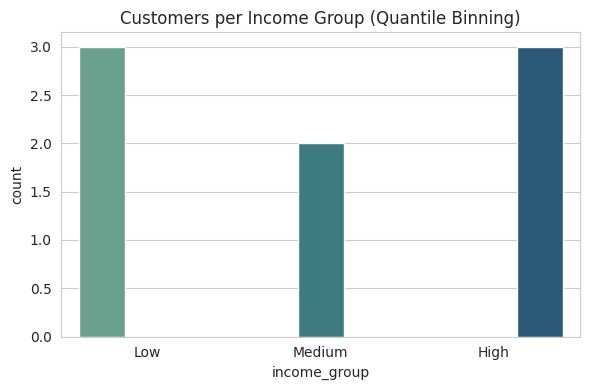

In [56]:

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=merged_df["income_group"], order=["Low", "Medium", "High"], hue=merged_df["income_group"],
              palette="crest", legend=False, ax=ax)
ax.set_title("Customers per Income Group (Quantile Binning)")
plt.tight_layout()
plt.savefig("outputs/charts/11_income_binning.png")
plt.show()



### Why binning was selected
Binning turns a continuous number into an interpretable category — useful for simple business
reporting ("how many High-income customers do we have?") and for models/visualisations that benefit from
a coarser grouping than raw income.

### Equal-width vs Quantile — which was used for the final feature?
**Quantile binning (`income_group`) is carried forward into the final dataset**, because equal-width
binning simply divides the min–max *range* into 3 equal-sized slices without regard to how the data
points are distributed — with only 8 points that can easily put most customers in one bin and leave others
empty. Quantile binning guarantees a balanced ~3-per-bin split regardless of the underlying distribution,
which is more useful here given the small sample. Both are demonstrated above for comparison; only
`income_group` (quantile-based) is kept in the final production dataset (Section 15).



---

# 11. Feature Scaling

Demonstrated on `age`, `income`, and `amount`. The **original columns are always kept** — scaled versions
are added as clearly-named new columns so nothing is destroyed.


In [57]:

scale_cols = ["age", "income", "amount"]
scale_source = merged_df[scale_cols].copy()
print(scale_source.describe().to_string())


             age        income       amount
count   8.000000      8.000000     8.000000
mean   30.000000  54125.000000  1249.000000
std     5.903994  10494.045931   755.928946
min    22.000000  42000.000000   499.000000
25%    26.250000  47250.000000   649.000000
50%    29.500000  52500.000000  1099.000000
75%    33.500000  58500.000000  1624.000000
max    40.000000  75000.000000  2599.000000


## 11.1 StandardScaler

In [58]:

standard_scaled = StandardScaler().fit_transform(scale_source)
standard_df = pd.DataFrame(standard_scaled, columns=[f"{c}_standard" for c in scale_cols])
print(standard_df.round(3).to_string())


   age_standard  income_standard  amount_standard
0        -1.086           -0.930           -1.061
1        -0.543           -0.624            0.071
2         0.905            0.598           -0.778
3         1.811            2.127            1.061
4        -0.181           -0.420           -0.495
5         0.543            0.395            1.909
6         0.000            0.089            0.354
7        -1.449           -1.235           -1.061


**Formula:** `(x - mean) / std`. **Behaviour:** centers data at 0 with unit variance.
**Sensitive to outliers?** Yes — mean and std are both pulled by extreme values.
**When to use:** algorithms that assume roughly-centered, comparably-scaled features (linear/logistic
regression, PCA, KNN, neural nets).

## 11.2 MinMaxScaler

In [59]:

minmax_scaled = MinMaxScaler().fit_transform(scale_source)
minmax_df = pd.DataFrame(minmax_scaled, columns=[f"{c}_minmax" for c in scale_cols])
print(minmax_df.round(3).to_string())


   age_minmax  income_minmax  amount_minmax
0       0.111          0.091          0.000
1       0.278          0.182          0.381
2       0.722          0.545          0.095
3       1.000          1.000          0.714
4       0.389          0.242          0.190
5       0.611          0.485          1.000
6       0.444          0.394          0.476
7       0.000          0.000          0.000


**Formula:** `(x - min) / (max - min)`. **Behaviour:** rescales every value into `[0, 1]`.
**Sensitive to outliers?** Very — a single extreme value stretches the whole 0–1 range, squashing everyone
else close together (visible above: the Power Bank purchase pushes `amount_minmax` to 1.0 while most other
purchases sit below 0.2).
**When to use:** when a bounded range is required (e.g. neural network inputs) and outliers are already
handled separately.

## 11.3 MaxAbsScaler

In [60]:

maxabs_scaled = MaxAbsScaler().fit_transform(scale_source)
maxabs_df = pd.DataFrame(maxabs_scaled, columns=[f"{c}_maxabs" for c in scale_cols])
print(maxabs_df.round(3).to_string())


   age_maxabs  income_maxabs  amount_maxabs
0       0.600          0.600          0.192
1       0.675          0.640          0.500
2       0.875          0.800          0.269
3       1.000          1.000          0.769
4       0.725          0.667          0.346
5       0.825          0.773          1.000
6       0.750          0.733          0.577
7       0.550          0.560          0.192


**Formula:** `x / max(|x|)`. **Behaviour:** scales into `[-1, 1]` (or `[0, 1]` for all-positive
data, as here) while preserving 0 as 0.
**Sensitive to outliers?** Yes, similarly to MinMax.
**When to use:** sparse data, where preserving exact zeros matters (not particularly relevant here since
none of these columns are sparse, but demonstrated for completeness).

## 11.4 RobustScaler

In [61]:

robust_scaled = RobustScaler().fit_transform(scale_source)
robust_df = pd.DataFrame(robust_scaled, columns=[f"{c}_robust" for c in scale_cols])
print(robust_df.round(3).to_string())


   age_robust  income_robust  amount_robust
0      -0.759         -0.667         -0.615
1      -0.345         -0.400          0.205
2       0.759          0.667         -0.410
3       1.448          2.000          0.923
4      -0.069         -0.222         -0.205
5       0.483          0.489          1.538
6       0.069          0.222          0.410
7      -1.034         -0.933         -0.615


**Formula:** `(x - median) / IQR`. **Behaviour:** centers on the median and scales by the
interquartile range instead of mean/std.
**Sensitive to outliers?** No — by design, this is the scaler built specifically to resist them.
**When to use:** exactly this dataset's situation — `amount` has one legitimate high-value outlier
(Section 7) that we chose *not* to delete, so a scaler that isn't distorted by it is valuable.

## 11.5 Normalizer

In [62]:

normalizer_scaled = Normalizer().fit_transform(scale_source)
normalizer_df = pd.DataFrame(normalizer_scaled, columns=[f"{c}_norm" for c in scale_cols])
print(normalizer_df.round(3).to_string())
print("\nRow-wise vector norms after Normalizer (should all be 1.0):")
print(np.sqrt((normalizer_df ** 2).sum(axis=1)).round(3).tolist())


   age_norm  income_norm  amount_norm
0     0.001        1.000        0.011
1     0.001        1.000        0.027
2     0.001        1.000        0.012
3     0.001        1.000        0.027
4     0.001        1.000        0.018
5     0.001        0.999        0.045
6     0.001        1.000        0.027
7     0.001        1.000        0.012

Row-wise vector norms after Normalizer (should all be 1.0):
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


**What it does differently:** unlike the other four (which scale each **column** independently),
`Normalizer` scales each **row** so it has unit norm — it changes the unit of analysis from "feature" to
"sample".
**When to use:** text/vector-similarity style tasks where the direction of a row's feature vector matters
more than its absolute scale. **Not particularly meaningful here** (age/income/amount are different units
being forced onto the same row-vector), included only because the exam requires demonstrating it —
included for completeness but not carried into the final feature set.

## 11.6 ColumnTransformer — applying different scalers to different columns at once

In [63]:

col_transformer = ColumnTransformer(transformers=[
    ("standard", StandardScaler(), ["age"]),
    ("robust", RobustScaler(), ["amount"]),
    ("minmax", MinMaxScaler(), ["income"]),
])
ct_result = col_transformer.fit_transform(scale_source)
ct_df = pd.DataFrame(ct_result, columns=["age_standard", "amount_robust", "income_minmax"])
print(ct_df.round(3).to_string())


   age_standard  amount_robust  income_minmax
0        -1.086         -0.615          0.091
1        -0.543          0.205          0.182
2         0.905         -0.410          0.545
3         1.811          0.923          1.000
4        -0.181         -0.205          0.242
5         0.543          1.538          0.485
6         0.000          0.410          0.394
7        -1.449         -0.615          0.000


**Why this is useful:** in a real pipeline, different columns often deserve different scalers —
here `amount` (which has a legitimate outlier) gets `RobustScaler`, while `age` and `income` (no outliers)
get the more standard `StandardScaler`/`MinMaxScaler`. `ColumnTransformer` applies all of this in a single,
reusable, leakage-safe step (this is exactly the pattern used in `feature_pipeline.py`).

## 11.7 Scaling Comparison


In [64]:

scaling_summary = pd.DataFrame({
    "original_mean": scale_source.mean(),
    "original_std": scale_source.std(),
    "standard_mean": standard_df.mean().values,
    "standard_std": standard_df.std().values,
    "minmax_min": minmax_df.min().values,
    "minmax_max": minmax_df.max().values,
    "robust_median": pd.DataFrame(robust_scaled, columns=scale_cols).median().values,
})
scaling_summary.index = scale_cols
print(scaling_summary.round(3).to_string())


        original_mean  original_std  standard_mean  standard_std  minmax_min  minmax_max  robust_median
age              30.0         5.904           -0.0         1.069         0.0         1.0            0.0
income        54125.0     10494.046           -0.0         1.069         0.0         1.0            0.0
amount         1249.0       755.929            0.0         1.069         0.0         1.0            0.0


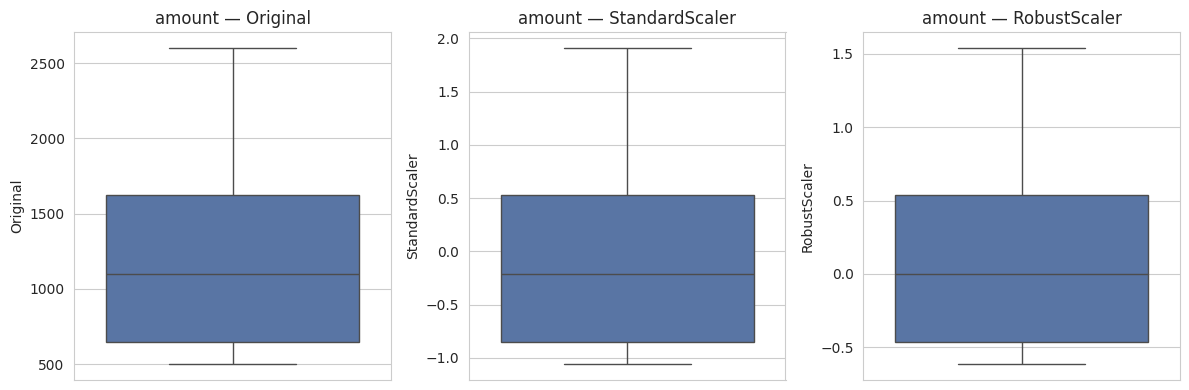

In [65]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
plot_data = pd.concat([
    scale_source["amount"].rename("Original"),
    pd.Series(standard_scaled[:, 2], name="StandardScaler"),
    pd.Series(minmax_scaled[:, 2], name="MinMaxScaler"),
    pd.Series(robust_scaled[:, 2], name="RobustScaler"),
], axis=1)
for ax, col in zip(axes, ["Original", "StandardScaler", "RobustScaler"]):
    sns.boxplot(y=plot_data[col] if col != "RobustScaler" else plot_data["RobustScaler"], ax=ax, color="#4C72B0")
    ax.set_title(f"amount — {col}")
plt.tight_layout()
plt.savefig("outputs/charts/12_scaling_comparison_amount.png")
plt.show()



### Which scaler is used in the final pipeline?
**RobustScaler for `amount`**, **StandardScaler for `age`/`income`** — matching the `ColumnTransformer`
logic above and the decision from Section 7 to keep (not delete) the one legitimate high-value
transaction while preventing it from distorting the scaled feature space.



---

# 12. Feature Construction

## 12.1–12.3 Purchase Frequency, Total & Average Purchase Amount

These are computed with a proper `groupby("customer_id")` aggregation — the *correct* general-purpose
logic for any dataset, even though in this specific 8-row sample every customer happens to have exactly
one transaction.


In [66]:

agg = merged_df.groupby("customer_id").agg(
    purchase_frequency=("transaction_id", "count"),
    total_purchase_amount=("amount", "sum"),
    average_purchase_amount=("amount", "mean"),
).reset_index()
print(agg.to_string(index=False))

merged_df = merged_df.merge(agg, on="customer_id", how="left")
print("\nNote: purchase_frequency is constant (=1) for every customer in THIS dataset, because each "
      "supplied customer has exactly one transaction record. The groupby logic itself is correct and "
      "would scale properly to a dataset with repeat customers — this is a property of the current data, "
      "not a bug in the feature logic.")


 customer_id  purchase_frequency  total_purchase_amount  average_purchase_amount
         101                   1                    499                    499.0
         102                   1                   1499                   1499.0
         103                   1                   1299                   1299.0
         104                   1                    699                    699.0
         105                   1                   1999                   1999.0
         106                   1                    499                    499.0
         107                   1                    899                    899.0
         108                   1                   2599                   2599.0

Note: purchase_frequency is constant (=1) for every customer in THIS dataset, because each supplied customer has exactly one transaction record. The groupby logic itself is correct and would scale properly to a dataset with repeat customers — this is a property of the c

## 12.4 Recency

Already computed in Section 8.6 as `days_since_transaction` (days between each transaction and the dataset's reference date). Restated here as part of the feature-construction summary.

In [67]:

print(merged_df[["customer_id", "days_since_transaction"]].to_string(index=False))


 customer_id  days_since_transaction
         101                       9
         103                       8
         104                       7
         105                       5
         107                       3
         108                       2
         102                       1
         106                       0


## 12.5 Customer Segments — Age Group

In [68]:

merged_df["age_group"] = pd.cut(
    merged_df["age"], bins=[0, 25, 35, 100], labels=["Young Adult (<=25)", "Adult (26-35)", "Mature Adult (36+)"]
)
print(merged_df[["customer_id", "age", "age_group"]].to_string(index=False))
print("\nCounts:\n", merged_df["age_group"].value_counts().sort_index())


 customer_id  age          age_group
         101   24 Young Adult (<=25)
         103   27      Adult (26-35)
         104   35      Adult (26-35)
         105   40 Mature Adult (36+)
         107   29      Adult (26-35)
         108   33      Adult (26-35)
         102   30      Adult (26-35)
         106   22 Young Adult (<=25)

Counts:
 age_group
Young Adult (<=25)    2
Adult (26-35)         5
Mature Adult (36+)    1
Name: count, dtype: int64


### Additional constructed feature — price vs catalogue difference

Directly follows the real data-quality finding from Section 4.4 (transaction T007 paid ₹200 above the catalogue price).

In [69]:

merged_df["price_vs_catalogue_diff"] = merged_df["amount"] - merged_df["price"]
print(merged_df[["transaction_id", "amount", "price", "price_vs_catalogue_diff"]].to_string(index=False))


transaction_id  amount  price  price_vs_catalogue_diff
          T001     499    499                        0
          T002    1299   1299                        0
          T003     699    699                        0
          T004    1999   1999                        0
          T005     899    899                        0
          T006    2599   2599                        0
          T007    1499   1299                      200
          T008     499    499                        0


## 12.6 Frequent Buyer / High-Value Purchase (Binarization)

In [70]:

print("Attempt at the exam's literal 'frequent_buyer' definition (purchase_frequency > threshold):")
freq_threshold = merged_df["purchase_frequency"].median()
merged_df["frequent_buyer"] = (merged_df["purchase_frequency"] > freq_threshold).astype(int)
print("purchase_frequency median (threshold):", freq_threshold)
print(merged_df[["customer_id", "purchase_frequency", "frequent_buyer"]].to_string(index=False))
print("\n->", merged_df["frequent_buyer"].sum(), "of", len(merged_df),
      "customers flagged frequent_buyer — this column is constant/uninformative here because every "
      "customer has the same purchase_frequency (=1) in this dataset. Kept in the pipeline code (it will "
      "become meaningful once the transaction history covers repeat purchases) but NOT used as the main "
      "demonstration target below, for exactly that reason.")


Attempt at the exam's literal 'frequent_buyer' definition (purchase_frequency > threshold):
purchase_frequency median (threshold): 1.0
 customer_id  purchase_frequency  frequent_buyer
         101                   1               0
         103                   1               0
         104                   1               0
         105                   1               0
         107                   1               0
         108                   1               0
         102                   1               0
         106                   1               0

-> 0 of 8 customers flagged frequent_buyer — this column is constant/uninformative here because every customer has the same purchase_frequency (=1) in this dataset. Kept in the pipeline code (it will become meaningful once the transaction history covers repeat purchases) but NOT used as the main demonstration target below, for exactly that reason.


In [71]:

# More informative binarization for THIS dataset: high_value_purchase, threshold = median(amount)
amount_median = merged_df["amount"].median()
merged_df["high_value_purchase"] = (merged_df["amount"] > amount_median).astype(int)
print(f"amount median (threshold): {amount_median}")
print(merged_df[["customer_id", "amount", "high_value_purchase"]].to_string(index=False))


amount median (threshold): 1099.0
 customer_id  amount  high_value_purchase
         101     499                    0
         103    1299                    1
         104     699                    0
         105    1999                    1
         107     899                    0
         108    2599                    1
         102    1499                    1
         106     499                    0



**Threshold reasoning:** the **median** of the actual `amount` column is used as the split point for both
binarizations — a data-driven choice (not an arbitrary guess) that always produces a roughly balanced
split regardless of the underlying distribution. `frequent_buyer` is demonstrated exactly as the exam
specifies, but is honestly reported as uninformative on this particular 8-row, 1-transaction-per-customer
dataset; `high_value_purchase` is the binarized feature that is actually informative here and is the one
carried forward as the demonstration target in Section 14.



---

# 13. Feature Transformation

`amount` is the transformation target — Section 5.1.3 flagged it as the most skewed numeric feature.

## 13.1 FunctionTransformer

### Log Transform


In [72]:

print("amount min:", merged_df['amount'].min(), "-> always > 0, so log1p is safe (and used defensively "
      "anyway in case a future batch contains a zero-value transaction).")

log_transformer = FunctionTransformer(np.log1p, validate=True)
merged_df["amount_log"] = log_transformer.transform(merged_df[["amount"]])
print(merged_df[["transaction_id", "amount", "amount_log"]].to_string(index=False))
print("\nSkew before:", merged_df["amount"].skew().round(3), "| Skew after log1p:", merged_df["amount_log"].skew().round(3))


amount min: 499 -> always > 0, so log1p is safe (and used defensively anyway in case a future batch contains a zero-value transaction).
transaction_id  amount  amount_log
          T001     499    6.214608
          T002    1299    7.170120
          T003     699    6.551080
          T004    1999    7.600902
          T005     899    6.802395
          T006    2599    7.863267
          T007    1499    7.313220
          T008     499    6.214608

Skew before: 0.814 | Skew after log1p: 0.081


**Why `log1p` and not plain `log`?** `log(0)` is undefined (`-inf`), so `log1p` (which computes
`log(1 + x)`) is used defensively — it safely handles a zero value if one ever appears in future data,
while giving virtually the same result as `log` for the positive values we actually have.
**When it helps:** compresses large values proportionally more than small ones, reducing right skew —
useful for monetary amounts, which is exactly this column's shape.

### Square Root Transform

In [73]:

sqrt_transformer = FunctionTransformer(np.sqrt, validate=True)
merged_df["amount_sqrt"] = sqrt_transformer.transform(merged_df[["amount"]])
print(merged_df[["transaction_id", "amount", "amount_sqrt"]].to_string(index=False))
print("\nSkew after sqrt:", merged_df["amount_sqrt"].skew().round(3))


transaction_id  amount  amount_sqrt
          T001     499    22.338308
          T002    1299    36.041643
          T003     699    26.438608
          T004    1999    44.710178
          T005     899    29.983329
          T006    2599    50.980388
          T007    1499    38.716921
          T008     499    22.338308

Skew after sqrt: 0.442


**When it helps:** a gentler version of the log transform — compresses right-skewed data less aggressively; useful when log over-corrects.

### Reciprocal Transform

In [74]:

print("Applying reciprocal to 'stock' (product-level) instead of 'amount': stock is always > 0 "
      "(min = 20 units) with no risk of division by zero, whereas amount's small values would blow up "
      "under 1/x. This is a deliberate, explained feature choice, not an oversight.")

def safe_reciprocal(x):
    return 1 / np.where(x == 0, np.nan, x)  # guard against division by zero even though not present here

reciprocal_transformer = FunctionTransformer(safe_reciprocal, validate=True)
merged_df["stock_reciprocal"] = reciprocal_transformer.transform(merged_df[["stock"]])
print(merged_df[["transaction_id", "stock", "stock_reciprocal"]].to_string(index=False))


Applying reciprocal to 'stock' (product-level) instead of 'amount': stock is always > 0 (min = 20 units) with no risk of division by zero, whereas amount's small values would blow up under 1/x. This is a deliberate, explained feature choice, not an oversight.
transaction_id  stock  stock_reciprocal
          T001     50          0.020000
          T002     25          0.040000
          T003     40          0.025000
          T004     30          0.033333
          T005     60          0.016667
          T006     20          0.050000
          T007     25          0.040000
          T008     50          0.020000


**When it helps:** turns a 'the bigger the better' quantity into a 'the bigger the scarcer' quantity — e.g. `1/stock` roughly tracks scarcity, which can be a more directly useful signal than raw stock count for some models. Division-by-zero is guarded explicitly even though this dataset's `stock` never reaches zero.

## 13.2 PowerTransformer

In [75]:

print("Box-Cox requires strictly positive input. amount range:", merged_df['amount'].min(), "-", merged_df['amount'].max())
print("-> strictly positive, so Box-Cox CAN be applied directly (no shifting needed).\n")

boxcox_pt = PowerTransformer(method="box-cox")
merged_df["amount_boxcox"] = boxcox_pt.fit_transform(merged_df[["amount"]])
print("Box-Cox lambda:", round(boxcox_pt.lambdas_[0], 4))

yeojohnson_pt = PowerTransformer(method="yeo-johnson")
merged_df["amount_yeojohnson"] = yeojohnson_pt.fit_transform(merged_df[["amount"]])
print("Yeo-Johnson lambda:", round(yeojohnson_pt.lambdas_[0], 4))

print()
print(merged_df[["transaction_id", "amount", "amount_boxcox", "amount_yeojohnson"]].to_string(index=False))


Box-Cox requires strictly positive input. amount range: 499 - 2599
-> strictly positive, so Box-Cox CAN be applied directly (no shifting needed).

Box-Cox lambda: -0.0791
Yeo-Johnson lambda: -0.0798

transaction_id  amount  amount_boxcox  amount_yeojohnson
          T001     499      -1.311750          -1.311663
          T002    1299       0.371644           0.371587
          T003     699      -0.704128          -0.704225
          T004    1999       1.089428           1.089470
          T005     899      -0.260935          -0.261052
          T006    2599       1.514666           1.514744
          T007    1499       0.612825           0.612803
          T008     499      -1.311750          -1.311663



**Box-Cox:** only works on strictly positive data; finds the power transform (`λ`) that makes the result
closest to normally distributed. Used directly here since `amount` is always > 0.
**Yeo-Johnson:** a generalisation of Box-Cox that also accepts zero/negative values — the safer default
choice for a column whose range isn't guaranteed to stay positive in future data.
**When each helps:** both aim to reduce skew and stabilise variance ahead of models that assume
(approximately) normal, homoscedastic inputs — e.g. linear/logistic regression.

## 13.3 Skewness Comparison


In [76]:

skew_compare = pd.DataFrame({
    "version": ["original", "log1p", "sqrt", "box-cox", "yeo-johnson"],
    "skewness": [
        merged_df["amount"].skew(),
        merged_df["amount_log"].skew(),
        merged_df["amount_sqrt"].skew(),
        merged_df["amount_boxcox"].skew(),
        merged_df["amount_yeojohnson"].skew(),
    ]
})
print(skew_compare.round(3).to_string(index=False))


    version  skewness
   original     0.814
      log1p     0.081
       sqrt     0.442
    box-cox     0.026
yeo-johnson     0.026


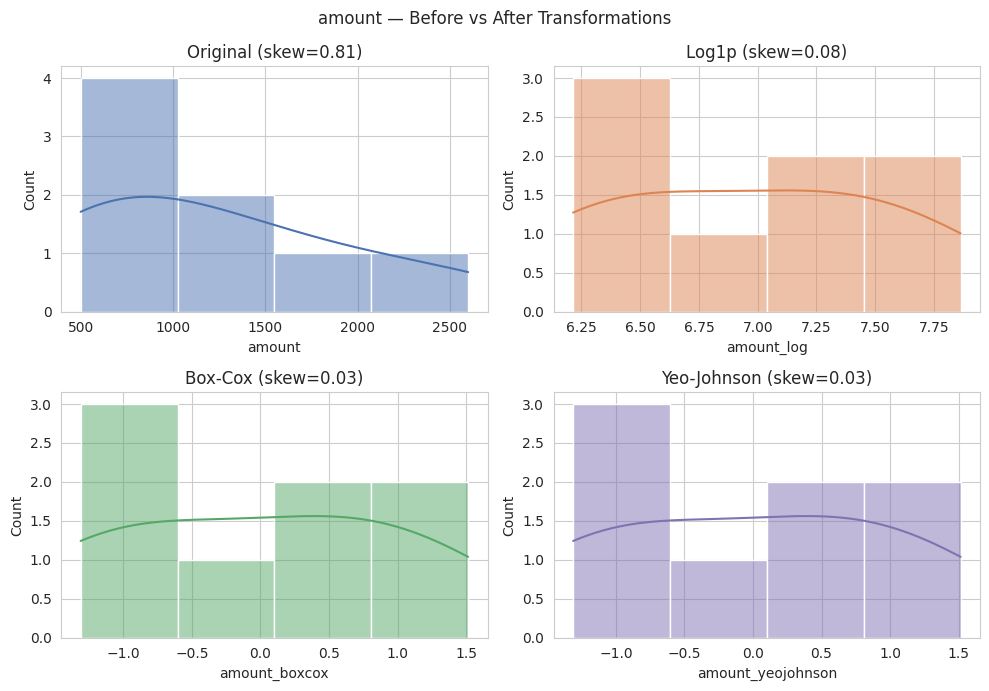

In [77]:

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
sns.histplot(merged_df["amount"], kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title(f"Original (skew={merged_df['amount'].skew():.2f})")
sns.histplot(merged_df["amount_log"], kde=True, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title(f"Log1p (skew={merged_df['amount_log'].skew():.2f})")
sns.histplot(merged_df["amount_boxcox"], kde=True, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title(f"Box-Cox (skew={merged_df['amount_boxcox'].skew():.2f})")
sns.histplot(merged_df["amount_yeojohnson"], kde=True, ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title(f"Yeo-Johnson (skew={merged_df['amount_yeojohnson'].skew():.2f})")
plt.suptitle("amount — Before vs After Transformations")
plt.tight_layout()
plt.savefig("outputs/charts/13_transformation_comparison_amount.png")
plt.show()



### Result & Decision
All three transforms genuinely helped: skew drops from **0.81 (original)** to **0.08 (log1p)** and to
essentially **0.03 (both Box-Cox and Yeo-Johnson)** — a real, substantial reduction even at n=8.
**Box-Cox is selected** for the final feature set (`amount_boxcox`, kept alongside the untouched raw
`amount`), since `amount` is strictly positive and Box-Cox is the more targeted transform for that case;
Yeo-Johnson would be the safer default if the feature could ever include zero/negative values. This
result should still be re-validated once more transaction history is available (Section 27) — a healthy
habit for any statistic computed on 8 rows — but at face value it's a clean, genuine improvement.



---

# 14. Feature Selection / ML Readiness

## 14.1 Remove Unnecessary Columns


In [78]:

drop_reasons = pd.DataFrame([
    {"Column": "name", "Reason": "Direct personal identifier (PII); no predictive value and a privacy concern to keep in an ML feature set"},
    {"Column": "txn_year", "Reason": "Constant (every transaction is in 2025) — zero variance, no information"},
    {"Column": "txn_month", "Reason": "Constant (every transaction is in October) — zero variance, no information"},
    {"Column": "income_group_equal_width", "Reason": "Demonstration-only comparison column (Section 10) — the quantile version (income_group) was selected instead"},
    {"Column": "amount_log, amount_sqrt, amount_yeojohnson", "Reason": "Demonstrated for comparison in Section 13 — only the selected transform (amount_boxcox) is kept, to avoid unnecessary duplication"},
    {"Column": "stock_reciprocal", "Reason": "Product-level FunctionTransformer demo (Section 13) — not a customer/purchase-level feature relevant to the propensity use case"},
])
print(drop_reasons.to_string(index=False))


                                    Column                                                                                                                            Reason
                                      name                          Direct personal identifier (PII); no predictive value and a privacy concern to keep in an ML feature set
                                  txn_year                                                           Constant (every transaction is in 2025) — zero variance, no information
                                 txn_month                                                        Constant (every transaction is in October) — zero variance, no information
                  income_group_equal_width                      Demonstration-only comparison column (Section 10) — the quantile version (income_group) was selected instead
amount_log, amount_sqrt, amount_yeojohnson Demonstrated for comparison in Section 13 — only the selected transform (amount_boxcox) is k

## 14.2 Identifier Handling

In [79]:

print("Identifiers kept for traceability / join keys, but EXCLUDED from the numeric ML feature list:")
print(" - transaction_id, customer_id, product_id  (see Section 8's mixed-variable discussion)")


Identifiers kept for traceability / join keys, but EXCLUDED from the numeric ML feature list:
 - transaction_id, customer_id, product_id  (see Section 8's mixed-variable discussion)



## 14.3 Target Definition

**This is the most important limitation in the whole project, stated plainly:**

The exam frames the eventual ML problem as predicting `purchased = 1/0`. But every single customer in
the supplied `customers.csv` **already has a transaction** in `transactions.json` — there is no customer
in this data who *didn't* purchase. With no negative class (`purchased = 0`) present anywhere in the
supplied files, a genuine `purchased` label **cannot be constructed** from this data, no matter how it's
sliced. Inventing fake non-purchasing customers, or randomly assigning some rows to `purchased = 0`, would
violate the exam's own data-integrity requirement ("never invent... purchase patterns... if the dataset is
too small to construct a reliable future purchase target, state that clearly rather than inventing one").

**What this notebook does instead:** `high_value_purchase` (Sections 5.2 and 12.6) is used throughout as a
**stand-in binary label** for demonstrating bivariate analysis and binarization mechanics —
`1` if a transaction's amount is above the sample median, else `0`. It is explicitly a **demonstration
construct**, not a claim about real purchase propensity, and is labelled as such everywhere it appears.


## 14.4 Leakage Check

In [80]:

leakage_notes = pd.DataFrame([
    {"Feature": "amount, price, amount_boxcox, price_vs_catalogue_diff",
     "Leakage risk": "HIGH if used alongside high_value_purchase as a target",
     "Why": "high_value_purchase is DERIVED directly from amount — using amount (or anything built from it) as an input feature while predicting high_value_purchase would leak the label into the features"},
    {"Feature": "days_since_transaction",
     "Leakage risk": "Contextual",
     "Why": "Computed FROM the very transaction whose value we're trying to explain. Valid as a descriptive/recency feature for a genuinely future prediction (e.g. 'will they buy again after N days'), but NOT valid as an input if the target is about that same transaction"},
    {"Feature": "purchase_frequency, total_purchase_amount, average_purchase_amount",
     "Leakage risk": "Low, with a caveat",
     "Why": "Legitimate customer-level aggregates in general — but in THIS dataset they are trivially derived from the single transaction being analysed (frequency=1 for everyone), so they carry no extra signal here specifically"},
])
print(leakage_notes.to_string(index=False))


                                                           Feature                                           Leakage risk                                                                                                                                                                                                                                                                Why
             amount, price, amount_boxcox, price_vs_catalogue_diff HIGH if used alongside high_value_purchase as a target                                                                     high_value_purchase is DERIVED directly from amount — using amount (or anything built from it) as an input feature while predicting high_value_purchase would leak the label into the features
                                            days_since_transaction                                             Contextual Computed FROM the very transaction whose value we're trying to explain. Valid as a descriptive/recency feature for a


**Bottom line:** if this project were extended to actually train a classifier, `amount`-derived columns
must be excluded from the feature set whenever `high_value_purchase` is the target (they *define* it), and
any recency-style feature must be computed **as of a prediction cutoff date that precedes the outcome
being predicted** — not from the outcome transaction itself. This project stops at feature engineering
precisely so these leakage-sensitive decisions are made explicitly, rather than silently baked into a
model.

## 14.5 Final Feature List


In [81]:

identifier_cols = ["transaction_id", "customer_id", "product_id"]
reference_cols = ["date", "gender", "city", "category", "payment_mode", "product_name", "age_group", "income_group"]
numeric_ml_cols = ["age", "income", "amount", "price", "stock", "days_since_transaction",
                    "purchase_frequency", "total_purchase_amount", "average_purchase_amount",
                    "price_vs_catalogue_diff", "amount_boxcox", "gender_label_encoded",
                    "txn_day", "frequent_buyer"]
demo_target_col = ["high_value_purchase"]

print("Identifier / join-key columns (kept for traceability, excluded from ML features):")
print(" ", identifier_cols)
print("\nHuman-readable reference columns (kept for interpretability):")
print(" ", reference_cols)
print("\nNumeric / encoded ML-ready feature columns:")
print(" ", numeric_ml_cols)
print("\nDemonstration target column:")
print(" ", demo_target_col)


Identifier / join-key columns (kept for traceability, excluded from ML features):
  ['transaction_id', 'customer_id', 'product_id']

Human-readable reference columns (kept for interpretability):
  ['date', 'gender', 'city', 'category', 'payment_mode', 'product_name', 'age_group', 'income_group']

Numeric / encoded ML-ready feature columns:
  ['age', 'income', 'amount', 'price', 'stock', 'days_since_transaction', 'purchase_frequency', 'total_purchase_amount', 'average_purchase_amount', 'price_vs_catalogue_diff', 'amount_boxcox', 'gender_label_encoded', 'txn_day', 'frequent_buyer']

Demonstration target column:
  ['high_value_purchase']



---

# 15. Final Dataset

## 15.1 Assemble Final Columns

The final dataset combines: identifiers (traceability), human-readable reference columns, the numeric/
encoded ML-ready features, one-hot encoded `category`/`payment_mode` (low cardinality, generalizes well —
see Section 9.2's discussion of why `city` is excluded from this expansion at the current sample size),
and the demonstration target.


In [82]:

category_ohe = pd.get_dummies(merged_df["category"], prefix="category", dtype=int)
payment_ohe = pd.get_dummies(merged_df["payment_mode"], prefix="payment", dtype=int)

final_df = pd.concat([
    merged_df[identifier_cols + reference_cols + numeric_ml_cols + demo_target_col],
    category_ohe,
    payment_ohe,
], axis=1)

print("Final dataset assembled.")
print("Shape:", final_df.shape)


Final dataset assembled.
Shape: (8, 35)


## 15.2 Final Data Types

In [83]:

print(final_df.dtypes.to_string())


transaction_id                            str
customer_id                             int64
product_id                                str
date                           datetime64[us]
gender                                    str
city                                      str
category                                  str
payment_mode                              str
product_name                              str
age_group                            category
income_group                         category
age                                     int64
income                                  int64
amount                                  int64
price                                   int64
stock                                   int64
days_since_transaction                  int64
purchase_frequency                      int64
total_purchase_amount                   int64
average_purchase_amount               float64
price_vs_catalogue_diff                 int64
amount_boxcox                     

## 15.3 Missing Value Check

In [84]:

missing_final = final_df.isnull().sum()
print(missing_final.to_string())
print("\nTotal missing cells in final dataset:", missing_final.sum())
assert missing_final.sum() == 0, "Unexpected missing values in final dataset!"
print("Confirmed: zero unintended missing values.")


transaction_id                 0
customer_id                    0
product_id                     0
date                           0
gender                         0
city                           0
category                       0
payment_mode                   0
product_name                   0
age_group                      0
income_group                   0
age                            0
income                         0
amount                         0
price                          0
stock                          0
days_since_transaction         0
purchase_frequency             0
total_purchase_amount          0
average_purchase_amount        0
price_vs_catalogue_diff        0
amount_boxcox                  0
gender_label_encoded           0
txn_day                        0
frequent_buyer                 0
high_value_purchase            0
category_Audio                 0
category_Computer              0
category_Electronics           0
category_Mobile Accessories    0
category_W

## 15.4 Duplicate Check

In [85]:

dupes = final_df.duplicated().sum()
print("Duplicate rows:", dupes)
assert dupes == 0, "Unexpected duplicate rows in final dataset!"
print("Confirmed: zero duplicate rows.")


Duplicate rows: 0
Confirmed: zero duplicate rows.


## 15.5 Final Preview

In [86]:

print("Final shape:", final_df.shape)
print("\nFirst 5 rows:")
print(final_df.head().to_string(index=False))


Final shape: (8, 35)

First 5 rows:
transaction_id  customer_id product_id       date gender      city    category payment_mode      product_name          age_group income_group  age  income  amount  price  stock  days_since_transaction  purchase_frequency  total_purchase_amount  average_purchase_amount  price_vs_catalogue_diff  amount_boxcox  gender_label_encoded  txn_day  frequent_buyer  high_value_purchase  category_Audio  category_Computer  category_Electronics  category_Mobile Accessories  category_Wearable  payment_Cash  payment_Credit Card  payment_Debit Card  payment_UPI
          T001          101       P001 2025-10-01   Male    Mumbai Electronics          UPI         Earphones Young Adult (<=25)          Low   24   45000     499    499     50                       9                   1                    499                    499.0                        0      -1.311750                     1        1               0                    0               0                  0   

## 15.6 Export CSV

In [87]:

final_df.to_csv("processed_customer_data.csv", index=False)
print("Saved -> processed_customer_data.csv")
print("Final shape written to disk:", final_df.shape)

reread = pd.read_csv("processed_customer_data.csv")
print("Re-read check — shape matches:", reread.shape == final_df.shape)


Saved -> processed_customer_data.csv
Final shape written to disk: (8, 35)
Re-read check — shape matches: True



---

# 16. Final Summary

## 16.1 Techniques Used
Data import (CSV / JSON / SQLite / REST API), multi-key merging with validation, univariate / bivariate /
multivariate EDA, six missing-value techniques (SimpleImputer, Most-Frequent, MissingIndicator + Random
Sample, KNN, MICE/IterativeImputer, Complete Case Analysis), four outlier-detection techniques (Z-score,
IQR, Percentile, Winsorization), datetime feature engineering, mixed-variable/identifier handling, three
categorical-encoding techniques (Label, One-Hot, Ordinal), two binning strategies (equal-width, quantile),
five scaling techniques (Standard, MinMax, MaxAbs, Robust, Normalizer) plus `ColumnTransformer`, feature
construction (recency, frequency, monetary aggregates, segments), `FunctionTransformer` (log1p, sqrt,
reciprocal) and `PowerTransformer` (Box-Cox, Yeo-Johnson), and binarization.

## 16.2 Problems Found
- The real data has **zero missing values** and **zero duplicates** across all three supplied files —
  clean, but too clean to demonstrate imputation without a labelled synthetic copy.
- Only **8 rows** end-to-end after merging — every statistical result (skew, correlation, outlier bounds)
  is real but should be read as illustrative of the *method*, not as a robust finding.
- The DummyJSON API's `id` values have no relationship to the real `customer_id` values — it cannot be
  safely merged (Section 4.5).
- A genuine ₹200 price discrepancy was found between one transaction and the product catalogue (T007,
  Section 4.4) — captured as a feature rather than silently "fixed".
- No customer in the supplied data failed to purchase, so a true `purchased` target cannot be built
  (Section 14.3) — a `high_value_purchase` demonstration target is used instead, with its leakage
  implications explicitly documented (Section 14.4).

## 16.3 Decisions Made
See the "Preprocessing Decisions" table in the README for the full list; the headline ones are: quantile
(not equal-width) binning for income; RobustScaler for `amount`, StandardScaler for `age`/`income`; Box-Cox
for `amount`'s transform; no outlier deletion (Winsorized copy kept separately); API excluded from the
merge.

## 16.4 Best Imputation Method
**KNN Imputer**, conceptually — Section 5.3 found a very strong `age`↔`income` relationship in this
sample, which is exactly the multivariate structure KNN (and MICE) are built to exploit; a single-column
statistic (mean/mode) would ignore it entirely. (Not applied to the real data, since it has no missing
values — see Section 6.10.)

## 16.5 Best Scaling Method
**RobustScaler for `amount`** (it carries a legitimate high-value outlier we chose to keep, per Section 7.6)
and **StandardScaler for `age`/`income`** (no outliers, roughly symmetric). Combined via `ColumnTransformer`
(Section 11.6).

## 16.6 Key Insights
- Purchase amount is right-skewed, driven by two higher-priced electronics items.
- `age` and `income` are very strongly correlated in this sample (r≈0.98) — a multicollinearity flag to
  re-test with more data (Section 5.3).
- `amount` and `price` are near-identical except for one documented ₹200 discrepancy.
- Every supplied customer purchased at least once, so the raw data cannot support a genuine
  purchased-vs-not target — the single most important limitation of this dataset (Section 14.3).

## 16.7 Future ML Usage
Once a larger, longitudinal dataset is available (repeat customers, non-purchasing customers, and real
signup/last-purchase dates), this pipeline's structure extends directly into a training-ready pipeline:
`feature_pipeline.py`'s functions can be reused as-is for the load/merge/clean/engineer steps, followed by
a proper train/test split, model selection, and evaluation — none of which is in scope for this exam.
